In [1]:
import csv
import ast
import pandas as pd
import numpy as np
import seaborn as sns
import random
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [2]:
def todata(dict1, dict2, val_type = 'MEAN'):
    valid_keys = list(dict1.keys() & dict2.keys())
    data1 = [dict1[x] for x in valid_keys]
    data2 = [dict2[x] for x in valid_keys]
    
    if type(data1[0]) == dict:
        data1 = [x[val_type] for x in data1]
        
    if type(data2[0]) == dict:
        data2 = [x[val_type] for x in data2]
    
    return valid_keys, data1, data2

def csv2dict(csv_file_path):
    result_dict = {}
    with open(csv_file_path, 'r') as csv_file:
        csv_reader = csv.reader(csv_file)
        
        for row in csv_reader:
            try:
                result_dict[row[0]] = ast.literal_eval(row[1])  # value is list
            except:
                result_dict[row[0]] = row[1]
                
    return result_dict

def scatter(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis'):
    valid_keys, data1, data2 = todata(dict1, dict2)
    plt.scatter(data1, data2, marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    # plt.savefig('scatter.png')
    plt.show()

def scatter_singleton2(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis'):
    valid_keys, data1, data2 = todata(dict1, dict2)
    colors = ['r' if key in singleton2 else 'b' for key in valid_keys]
    
    plt.scatter(data1, data2, marker='o', color=colors, alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    # plt.savefig('scatter.png')
    plt.show()
    
def scatter_singleton3(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis'):
    #     plt.plot(folditer2cpdNumFull.values(), color='k', alpha=0.3)
    
    valid_keys, data1, data2 = todata(dict1, dict2)
    colors = ['r' if key in singleton2 else 'b' for key in valid_keys]
    
    plt.scatter(data1, data2, marker='o', color=colors, alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    # plt.savefig('scatter.png')
    plt.show()

cpd2name = csv2dict('../data/assets/cpd2nameShort.csv')
rn2cpd_SI = csv2dict('../data/assets/rn2cpds_SI.csv')
rn2eqn_SI = csv2dict('../data/assets/rn2eqn_SI.csv')
rn2reversible = csv2dict('../data/assets/rn2reversible.csv')

In [3]:
from bokeh.plotting import figure, output_file, show
from bokeh.models import HoverTool

x2name = csv2dict('../data/assets/xgroup2/xgroup2name.csv')

# What's missing?

In [4]:
batm = pd.read_pickle('../no_look_ahead_rules_ignore_versions.pkl/2023-09-12_17-32-36_no_look_ahead_rules_ignore_versions_3141.pkl.gz')

In [5]:
df_cpd = pd.read_csv('pro_pero/pro_pero_cpds_folditer.csv', index_col=0)
df_fold = pd.read_csv('pro_pero/pro_pero_folds_folditer.csv', index_col=0)
df_rn = pd.read_csv('pro_pero/pro_pero_rns_folditer.csv', index_col=0)

In [6]:
len(batm.cpds_folditer), len(batm.folds_folditer), len(batm.rns_folditer)

(4318, 399, 7708)

In [7]:
len(df_cpd), len(df_fold), len(df_rn)

(4294, 398, 7680)

In [8]:
set(batm.folds_folditer) - set(df_fold.index)

{'558'}

In [9]:
# X558 |ds_a/b/e= 0.0 0.0 0.91 |fo=239.1 |ns=4315 |#rn=1 |grp2 |aux |Xname=N/A |e_only
#       |map00565: Ether lipid metabolism|O2=0:0/1 |alpha duplicates or obligate multimers

In [10]:
for c in set(batm.cpds_folditer) - set(df_cpd.index):
    print(c, cpd2name[c])

C00638 Long-chain fatty acid
C03968 1-Alkyl-sn-glycero-3-phosphate
C19861 3-Hydroxy fatty acid
C05102 alpha-Hydroxy fatty acid
C04476 1-Alkyl-sn-glycero-3-phosphoethanolamine
C04080 N-(Long-chain-acyl)ethanolamine
C03715 O-Alkylglycerone phosphate
C04598 2-Acetyl-1-alkyl-sn-glycero-3-phosphocholine
C21886 omega-Hydroxy-long-chain fatty acid
C22173 Harderoheme III
C02773 1-Alkyl-sn-glycerol
C04317 1-Organyl-2-lyso-sn-glycero-3-phosphocholine
C00609 Long-chain aldehyde
C01264 2-Acetyl-1-alkyl-sn-glycero-3-phosphate
C21763 Long-chain alkane
C03129 Long-chain acid anion
C04305 N-Long-chain-fatty-acyl-L-glutamate
C00339 Long-chain alcohol
C03820 1-Alkyl-2-acetyl-sn-glycerol
C00347 Long-chain carboxylate
C04202 Long-chain-fatty-acyl ethyl ester
C01371 Alkane
C02446 O-Alkylglycerone
C20683 Long-chain acyl-[acyl-carrier protein]


In [11]:
set(df_cpd.index) - set(batm.cpds_folditer)  # no new cpds

set()

In [12]:
H2O2_rns = ['R00017_v1', 'R03532_v1', 'R09507_v1', 'R09740_v1', 'R09741_v1', 'R11522', 'R12455', 'R12454']

In [13]:
# reverse direction is discovered for all H2O2_rns? But some are BEFORE 02/H2O2. They get 'blocked'?

for rn in H2O2_rns:
    print(rn, rn in df_rn.index, np.mean(df_rn.loc[rn]))

R00017_v1 True 141.265625
R03532_v1 True 136.75
R09507_v1 True 136.75
R09740_v1 True 283.90625
R09741_v1 True 283.90625
R11522 True 136.75
R12455 True 136.75
R12454 True 283.90625


In [14]:
check = set()
for rn in H2O2_rns:
    print(rn, rn2eqn_SI[rn], rn2reversible[rn])
    for c in rn2cpd_SI[rn]:
        check.add(c[-6:])

R00017_v1 2C00125 + 2C00001 + Z00025 => 2C00126 + C00027 + Z00025 False
R03532_v1 2C00001 + C00028 + Z00025 + 2C00001 + C00028 + Z00025 => C00030 + C00027 + Z00025 + C00030 + C00027 + Z00025 False
R09507_v1 C01335 + C00001 + Z00025 + Z00010 => C01371 + C00027 + Z00025 + Z00010 True
R09740_v1 C05102 + C00001 + Z00025 => C00162 + C00027 + Z00025 True
R09741_v1 C19861 + C00001 + Z00025 => C00162 + C00027 + Z00025 True
R11522 2C00011 + 4C00001 + C00032 => 2C00027 + C21284 True
R12455 2C00001 + C00032 + C00011 => C22173 + C00027 True
R12454 2C00001 + C22173 + C00011 => C21284 + C00027 True


In [15]:
for c in check:
    print(c, c in df_cpd.index, cpd2name[c])

C00030 True Reduced acceptor
C00028 True Acceptor
C21284 True Fe-coproporphyrin III
C00001 True H2O
Z00010 True Cytochrome
C00032 True Heme
C19861 False 3-Hydroxy fatty acid
C00011 True CO2
C22173 False Harderoheme III
C05102 False alpha-Hydroxy fatty acid
C00125 True Ferricytochrome c
C00162 True Fatty acid
C00027 True Hydrogen peroxide
Z00025 True Heme
C01371 False Alkane
C01335 True ROH
C00126 True Ferrocytochrome c


In [16]:
# R09740_v1 "C05102" + C00001 + Z00025 => C00162 + C00027 + Z00025
# R09741_v1 "C19861" + C00001 + Z00025 => C00162 + C00027 + Z00025

# R09507_v1 C01335 + C00001 + Z00025 + Z00010 => "C01371" + C00027 + Z00025 + Z00010

In [17]:
# none of the missing reacions are H2O2_rns

for rn in set(batm.rns_folditer) - set(df_rn.index):
    print(rn, rn in H2O2_rns)

R04311_v1 False
R09484_v1 False
RZ_268 False
R04362_v1 False
R03437 False
R04126 False
R04452 False
R03454 False
R04043 False
R01406 False
R09485_v1 False
R02041 False
R04321_v1 False
R02682 False
R04321_v2 False
R01998 False
R09466_v1 False
R09485_v2 False
R12329_v1 False
R04360 False
R10551 False
R12072_v1 False
R03944 False
R02039 False
R09484_v2 False
R03455 False
R02040 False
R11915_v1 False


In [18]:
cpd2name['C00609'], 'C00609' in df_cpd.index

('Long-chain aldehyde', False)

In [19]:
for c in ['C00347', 'C00237', 'C01371']:
    print(c, cpd2name[c], batm.cpds_folditer[c], c in df_cpd.index)

C00347 Long-chain carboxylate 170 False
C00237 CO 103 True
C01371 Alkane 170 False


In [20]:
for c in ['C00339', 'C00609']:
    print(c, cpd2name[c], batm.cpds_folditer[c], c in df_cpd.index)

C00339 Long-chain alcohol 170 False
C00609 Long-chain aldehyde 170 False


In [21]:
for c in ['C03715', 'C03129']:
    print(c, cpd2name[c], batm.cpds_folditer[c], c in df_cpd.index)

C03715 O-Alkylglycerone phosphate 170 False
C03129 Long-chain acid anion 170 False


### check the generic cpds

In [22]:
for c in ['C00609', 'C00347', 'C00339', 'C03129', 'C03372', 'C03715']:
     print(c, c in df_cpd.index, cpd2name[c])

C00609 False Long-chain aldehyde
C00347 False Long-chain carboxylate
C00339 False Long-chain alcohol
C03129 False Long-chain acid anion
C03372 True Acylglycerone phosphate
C03715 False O-Alkylglycerone phosphate


In [23]:
np.mean(df_cpd.loc['C03372']), np.std(df_cpd.loc['C03372'])

(113.4375, 2.983679565570003)

# let's analyze the data

In [24]:
df_cpd

,2024-05-30_12-50-25,2024-05-30_09-49-49,2024-05-30_04-22-27,2024-05-30_14-02-36,2024-05-31_01-27-23,2024-05-30_23-03-20,2024-05-30_03-09-15,2024-05-30_20-39-02,2024-05-30_22-27-11,2024-05-30_09-13-53,...,2024-05-31_07-27-59,2024-05-30_19-27-02,2024-05-30_13-26-24,2024-05-31_05-03-59,2024-05-31_11-38-33,2024-05-31_11-02-16,2024-05-31_09-14-54,2024-05-30_21-51-15,2024-05-30_11-02-28,2024-05-30_06-11-54
C00288,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
C00048,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
C00150,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
C00080,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
C00282,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C01010,354,355,356,355,354,353,355,354,357,353,...,354,353,355,354,355,356,354,353,355,356
C05825,356,353,355,356,355,354,353,355,356,355,...,355,354,356,355,356,355,356,354,353,355
C05161,356,353,355,356,355,354,353,355,356,355,...,355,354,356,355,356,355,356,354,353,355
C20423,359,357,360,360,357,356,358,358,359,359,...,360,356,360,356,358,361,360,358,358,357


In [25]:
df_cpd['2024-05-30_12-50-25']

C00288      0
C00048      0
C00150      0
C00080      0
C00282      0
         ... 
C01010    354
C05825    356
C05161    356
C20423    359
C20422    360
Name: 2024-05-30_12-50-25, Length: 4294, dtype: int64

In [26]:
df_optimal = pd.read_csv('../cpds_folditer_optimal_1000runs.csv', index_col=0)

In [27]:
# after
fo2cpds_list = []
for run in df_cpd.columns:  # 64 runs
    fo2cpds = {}
    for c, order in df_cpd[run].items():
        if order not in fo2cpds.keys():
            fo2cpds[order] = [c]
        else:
            fo2cpds[order].append(c)
    fo2cpds_list.append(fo2cpds)
    
fo2cpdNum_list = []
for run in fo2cpds_list:                   
    fo2cpdNum = {}
    cumm = 0
    for i in range(0, max(run.keys())): 
        if i in run.keys():
            cumm += len(run[i])
        fo2cpdNum[i] = cumm
    fo2cpdNum_list.append(fo2cpdNum)
    
# before
fo2cpds_list_before = []
for run in df_optimal.columns:  # 1000 optimal runs
    fo2cpds = {}
    for c, order in df_optimal[run].items():
        if order not in fo2cpds.keys():
            fo2cpds[order] = [c]
        else:
            fo2cpds[order].append(c)
    fo2cpds_list_before.append(fo2cpds)
    
fo2cpdNum_list_before = []
for run in fo2cpds_list_before:                   
    fo2cpdNum = {}
    cumm = 0
    for i in range(0, max(run.keys())): 
        if i in run.keys():
            cumm += len(run[i])
        fo2cpdNum[i] = cumm
    fo2cpdNum_list_before.append(fo2cpdNum)

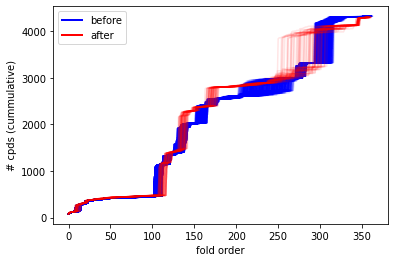

In [28]:
for run in fo2cpdNum_list_before:
    plt.plot(run.keys(), run.values(), color='blue', alpha = 0.1,zorder=2)
for run in fo2cpdNum_list:
    plt.plot(run.keys(), run.values(), color='red', alpha = 0.1,zorder=2)
plt.xlabel('fold order')
plt.ylabel('# cpds (cummulative)')

# legend
custom_lines = [Line2D([0], [0], color='blue', lw=2),
                Line2D([0], [0], color='red', lw=2)]
plt.legend(custom_lines, ['before', 'after'], loc='upper left')

# plt.savefig('fold_order_vs_cumm_cpds_pro_pero.svg', dpi=300, bbox_inches = 'tight')
plt.show()

### Where are the key compounds on this graph?

In [29]:
x2foAveNONE = csv2dict('../data/assets/xgroup2/xgroup2foMeanStdNONE.csv')

In [30]:
# from pre-expansion
cpds = ['Z00035', 'C00002', 'C00004', 'C00019', 'C00010', 'C00016', 'Z00047', 'Z00009']

# from vanilla (+ FMN, AcetylCoA, isopentenyl diphosphate, oxygen)
cpds = ['C00007','C00024','C00061','C00129','Z00014', 'Z00035', 'C00002', 'C00004', 'C00019', 'C00010', 'C00016', 'Z00047', 'Z00009']

In [31]:
batm.cpds_folditer[c]

358

In [32]:
np.mean(df_optimal.loc['C00004'])

107.511

In [34]:
x2foAve_64 = {}
for x in df_fold.index:
    x2foAve_64[x] = [np.mean(df_fold.loc[x]), np.std(df_fold.loc[x])]

In [35]:
x2foAveNONE['3997']

[304.303, 5.128273686144296]

In [36]:
x2foAve_64['3997']

[266.921875, 21.381435206374128]

In [37]:
group1 = {'3997', '1', '4011', '253', '7574', '875', '206', '3016', '328', '2486', '212', '148', '2002', '325', '4952', '218', '184', '7577', '2005', '2007', '4953', '7501', '7584', '7579', '297', '2492', '7523', '101', '141', '7544', '109', '2003', '2004', '602', '330', '304', '327'}

In [38]:
# for which folds did the averageFO change a lot?
# for 74 folds, average fold order changed by +/- 37 or more

plus37 = []
for x in x2foAveNONE.keys():
    if x != '558':
        if abs(x2foAveNONE[x][0] - x2foAve_64[x][0]) > 37:
            print(x, x2foAveNONE[x], x2foAve_64[x], x in group1)
            plus37.append(x)
print(len(plus37))

2492 [136.405, 2.9060239159373755] [90.96875, 6.921363553339761] True
330 [170.905, 3.5213598225685487] [129.390625, 2.842848414772585] True
243 [193.885, 7.698296889572394] [148.28125, 2.9867873103888734] False
147 [194.143, 7.285228273705636] [151.859375, 2.7549227955380164] False
6096 [239.529, 20.063328711856364] [276.546875, 30.72200437364683] False
4111 [239.232, 20.331408608357663] [282.90625, 30.894335418285017] False
842 [238.744, 20.101205535987138] [278.546875, 30.88331349992055] False
319 [239.61, 19.828159269079922] [281.640625, 32.97222656432797] False
876 [239.337, 19.53815321364842] [285.5, 31.048852635806046] False
305 [237.777, 19.910682333862894] [282.859375, 33.4686734067751] False
3001 [239.414, 20.187436786278738] [280.28125, 30.663735069907904] False
3687 [239.151, 19.91783620276058] [158.28125, 2.8254908312539255] False
316 [233.09, 16.63562141911146] [186.015625, 2.8912161557681917] False
102 [233.642, 16.408895026783494] [183.390625, 2.649393724868956] False
5

In [39]:
x2foAveNONE.pop('558')

[239.102, 20.0076884222041]

In [40]:
x2foAve_64.pop('spontaneous')
x2foAve_64.pop('fold_independent')

[0.0, 0.0]

In [41]:
len(x2foAveNONE), len(x2foAve_64)

(396, 396)

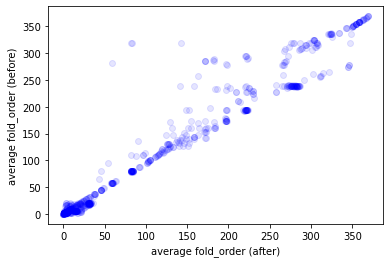

In [42]:
scatter(x2foAve_64, x2foAveNONE, 'average fold_order (after)', 'average fold_order (before)')

In [43]:
# bokeh plot: average fold order

d1 = {key: value[0] for key, value in x2foAve_64.items()}
d2 = {key: value[0] for key, value in x2foAveNONE.items()}

output_file("annotated_plot.html")
p = figure(plot_width=800, plot_height=800, title="average fold_order (after) vs. average fold order (before)")

# Add annotations
# source = {'x': list(group12iter.values()), 'y': y_values, 'label': ['X' + str(key) for key in group12iter.keys()]}
key, data1, data2 = todata(d1, d2)
source = {'x': data1, 'y': data2, 'label': [f"X{key} " + x2name.get(key, 'no X name') for key in key]}
p.scatter('x', 'y', source=source, size=10, color='blue')

# Add hover tool
hover = HoverTool()
hover.tooltips = [("folditer", "@x"), ("fold", "@label")]
p.add_tools(hover)

# Customize plot
p.xaxis.axis_label = 'average fold order (after)'
p.yaxis.axis_label = 'average fold order (before)'
p.xaxis.ticker = [50, 100, 150, 200, 250, 300, 350]  # Convert range to list
p.xgrid.grid_line_color = None

# Show the plot
show(p)

# fastest & slowest

## fastest

In [44]:
max_area = [0, 0]
index = 0
for run in fo2cpdNum_list:
    area = sum(run.values())
    if area > max_area[1]:
        max_area = [index, area]
    index += 1
max_area

[16, 835700]

In [45]:
df_cpd.columns[16]

'2024-05-31_03-51-45'

In [46]:
fastest = pd.read_pickle('../10AAprotein_peroxideFix/2024-05-31_03-51-45.pkl.gz')

## slowest

In [47]:
min_area = [0, 100000000]
index = 0
for run in fo2cpdNum_list:
    area = sum(run.values())
    if area < min_area[1]:
        min_area = [index, area]
    index += 1
min_area

[26, 762381]

In [48]:
df_cpd.columns[26]

'2024-05-30_01-20-39'

In [49]:
slowest = pd.read_pickle('../10AAprotein_peroxideFix/2024-05-30_01-20-39.pkl.gz')

## annotate folds / cpds

### fastest

In [50]:
folditer2rns = {}
for rn, i in fastest.rns_folditer.items():
    if i not in folditer2rns.keys():
        folditer2rns[i] = []
    folditer2rns[i].append(rn)
    
folditer2folds = {}
for rn, i in fastest.folds_folditer.items():
    if i not in folditer2folds.keys():
        folditer2folds[i] = []
    folditer2folds[i].append(rn)
    
multiple = []
for i, folds in folditer2folds.items():
    if len(folds) > 1:
        multiple.append(i)

176


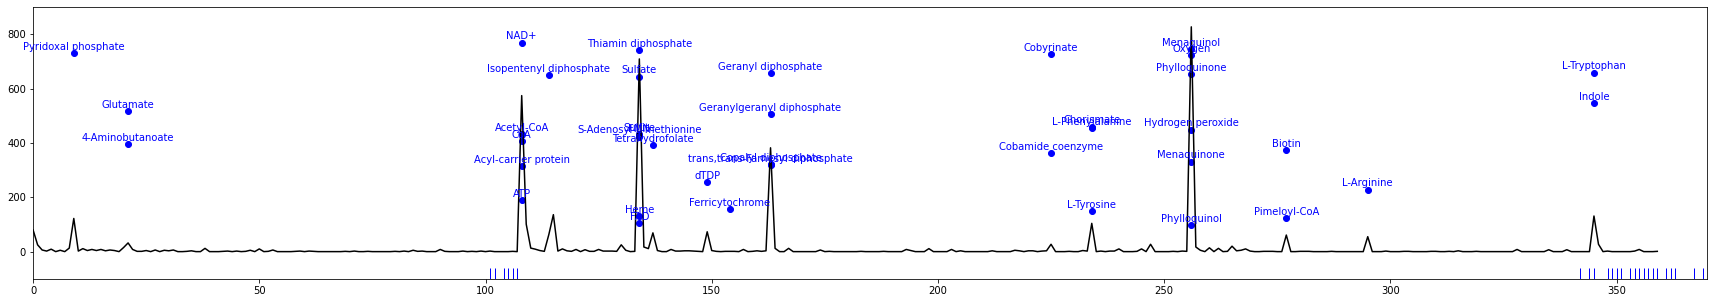

In [51]:
folditer2cpd = {}
for c, order in fastest.cpds_folditer.items():
    if order not in folditer2cpd.keys():
        folditer2cpd[order] = [c]
    else:
        folditer2cpd[order].append(c)
print(len(folditer2cpd))

folditer2cpdNum = {}
for fold in folditer2cpd.keys():
    folditer2cpdNum[fold] = len(folditer2cpd[fold])

folditer2cpdNumFull = {}
for i in range(0, max(folditer2cpd.keys())):
    if i not in folditer2cpdNum.keys():
        folditer2cpdNumFull[i] = 0
    else:
        folditer2cpdNumFull[i] = folditer2cpdNum[i]
        
cpd2iter = {}

for cpd in ['C00018', 'C00302', 'C00334', 'C11440', 'C00002', 'C00003', 'C00010', 'C00024', 'C00129', 'C00068', 'C00019', 'C00101', 'C00016', 'C00061', 'C00363', 'C00194', 'C00062', 'C00007', 'C00448', 'C11901', 'C00341', 'C00353', 'C00923', 'C00463', 'C00229', 'C05819', 'C03313', 'C00027', 'C00032', 'C00059', 'C00094', 'C05773', 'C00251', 'C00082', 'C00079', 'C00078', 'C02059', 'C00828', 'C01063', 'C00120']:
    for folditer in folditer2cpd.keys():
        for c in folditer2cpd[folditer]:
            if c == cpd:
                cpd2iter[c] = folditer
                
plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFull.values(), color='k')

sns.rugplot(multiple, height=0.04, color='blue')  # double fold injection

# Add annotations
for key, value in cpd2iter.items():
    position = random.randint(100, 800)
    plt.text(value, position, cpd2name[key], ha='center', va='bottom', color='blue')
    plt.scatter(value, position-5, color='b')

plt.xlim([0, 370])
plt.ylim([-100, 900])
# plt.savefig('pro_pero_fastest_cpd_annotated.svg', dpi=300, bbox_inches='tight')
plt.show()

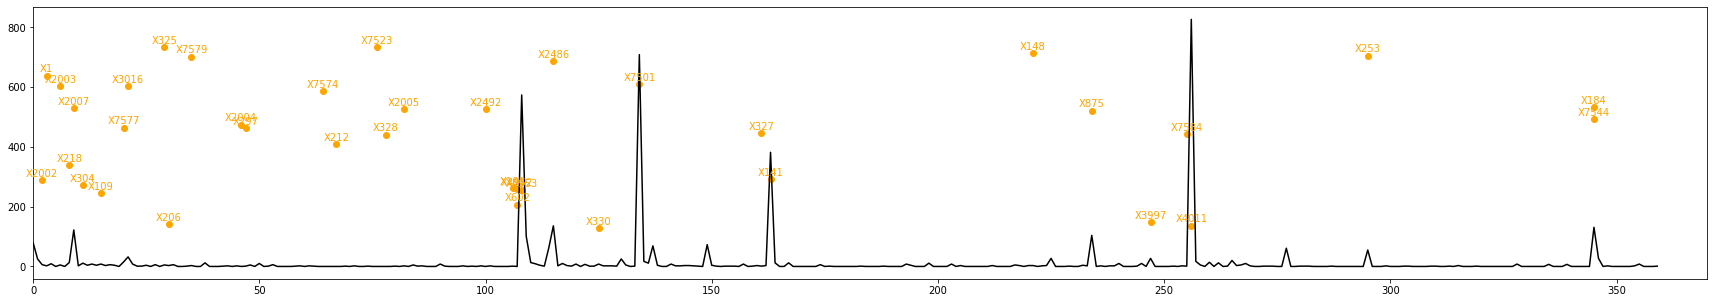

In [52]:
group12iter = {}
for x in group1:
    group12iter[x] = fastest.folds_folditer[x]

plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFull.values(), color='k')

# Add annotations
for key, value in group12iter.items():
    position = random.randint(100, 800)
    plt.text(value, position, 'X'+str(key), ha='center', va='bottom', color='orange')
    plt.scatter(value, position-5, color='orange')

plt.xlim([0, 370])
# plt.savefig('pro_pero_fastest_fold_annotated.svg', dpi=300, bbox_inches='tight')
plt.show()

In [53]:
aa = ['C00037', 'C00077', 'C00041', 'C00097', 'C00049', 'C00025', 'C00079', 'C00135', 'C00407', 'C00047', 'C00123', 'C00073', 'C00152', 'C00148', 'C00064', 'C00062', 'C00065', 'C00188', 'C00183', 'C00078', 'C00082']

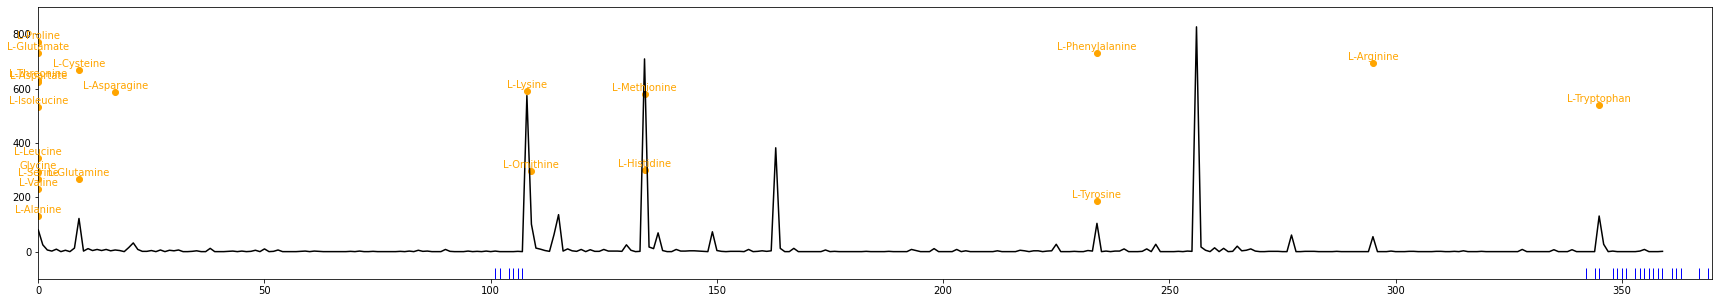

In [54]:
aa2iter = {}
for x in aa:
    aa2iter[x] = fastest.cpds_folditer[x]

plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFull.values(), color='k')

sns.rugplot(multiple, height=0.04, color='blue')  # double fold injection

# Add annotations
for key, value in aa2iter.items():
    position = random.randint(100, 800)
    plt.text(value, position, cpd2name[key], ha='center', va='bottom', color='orange')
    plt.scatter(value, position-5, color='orange')

plt.xlim([0, 370])
plt.ylim([-100, 900])
# plt.savefig('pro_pero_fastest_aa_annotated.svg', dpi=300, bbox_inches='tight')
plt.show()

### slowest

In [55]:
folditer2rns = {}
for rn, i in slowest.rns_folditer.items():
    if i not in folditer2rns.keys():
        folditer2rns[i] = []
    folditer2rns[i].append(rn)
    
folditer2folds = {}
for rn, i in slowest.folds_folditer.items():
    if i not in folditer2folds.keys():
        folditer2folds[i] = []
    folditer2folds[i].append(rn)
    
multiple = []
for i, folds in folditer2folds.items():
    if len(folds) > 1:
        multiple.append(i)

170


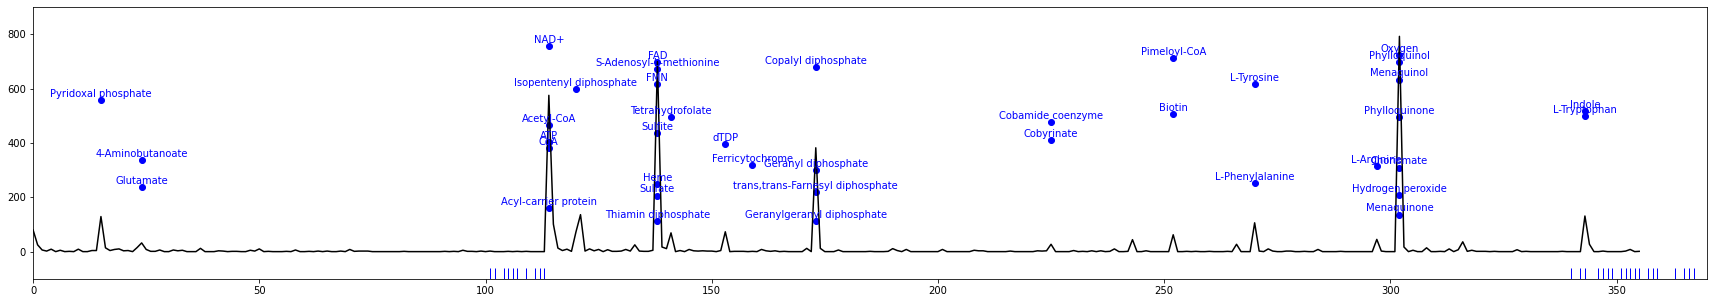

In [56]:
folditer2cpd = {}
for c, order in slowest.cpds_folditer.items():
    if order not in folditer2cpd.keys():
        folditer2cpd[order] = [c]
    else:
        folditer2cpd[order].append(c)
print(len(folditer2cpd))

folditer2cpdNum = {}
for fold in folditer2cpd.keys():
    folditer2cpdNum[fold] = len(folditer2cpd[fold])

folditer2cpdNumFull = {}
for i in range(0, max(folditer2cpd.keys())):
    if i not in folditer2cpdNum.keys():
        folditer2cpdNumFull[i] = 0
    else:
        folditer2cpdNumFull[i] = folditer2cpdNum[i]
        
cpd2iter = {}

for cpd in ['C0007', 'C00018', 'C00302', 'C00334', 'C11440', 'C00002', 'C00003', 'C00010', 'C00024', 'C00129', 'C00068', 'C00019', 'C00101', 'C00016', 'C00061', 'C00363', 'C00194', 'C00062', 'C00007', 'C00448', 'C11901', 'C00341', 'C00353', 'C00923', 'C00463', 'C00229', 'C05819', 'C03313', 'C00027', 'C00032', 'C00059', 'C00094', 'C05773', 'C00251', 'C00082', 'C00079', 'C00078', 'C02059', 'C00828', 'C01063', 'C00120']:
    for folditer in folditer2cpd.keys():
        for c in folditer2cpd[folditer]:
            if c == cpd:
                cpd2iter[c] = folditer
                
plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFull.values(), color='k')

sns.rugplot(multiple, height=0.04, color='blue')  # double fold injection

# Add annotations
for key, value in cpd2iter.items():
    position = random.randint(100, 800)
    plt.text(value, position, cpd2name[key], ha='center', va='bottom', color='blue')
    plt.scatter(value, position-5, color='b')

plt.xlim([0, 370])
plt.ylim([-100, 900])
# plt.savefig('pro_pero_slowest_cpd_annotated.svg', dpi=300, bbox_inches='tight')
plt.show()

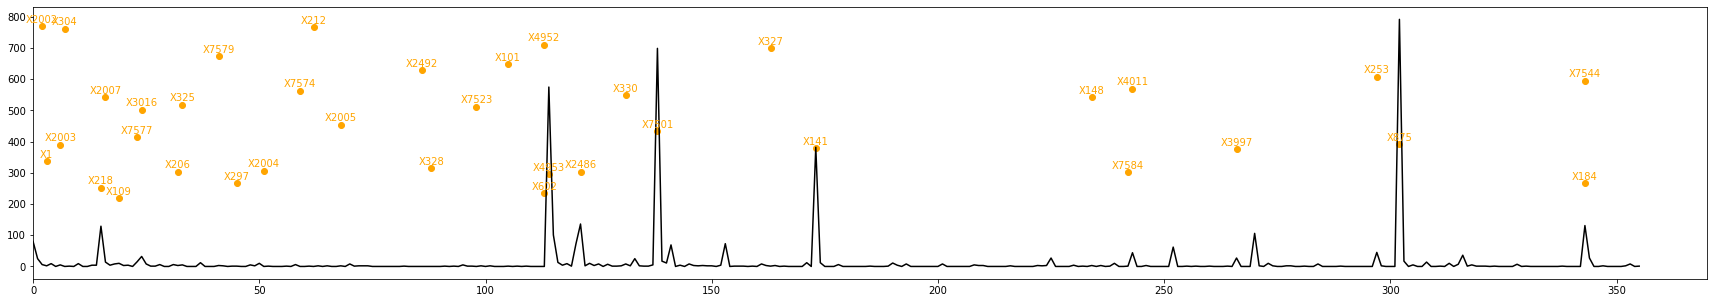

In [57]:
group12iter = {}
for x in group1:
    group12iter[x] = slowest.folds_folditer[x]

plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFull.values(), color='k')

# Add annotations
for key, value in group12iter.items():
    position = random.randint(100, 800)
    plt.text(value, position, 'X'+str(key), ha='center', va='bottom', color='orange')
    plt.scatter(value, position-5, color='orange')

plt.xlim([0, 370])
# plt.savefig('pro_pero_slowest_fold_annotated.svg', dpi=300, bbox_inches='tight')
plt.show()

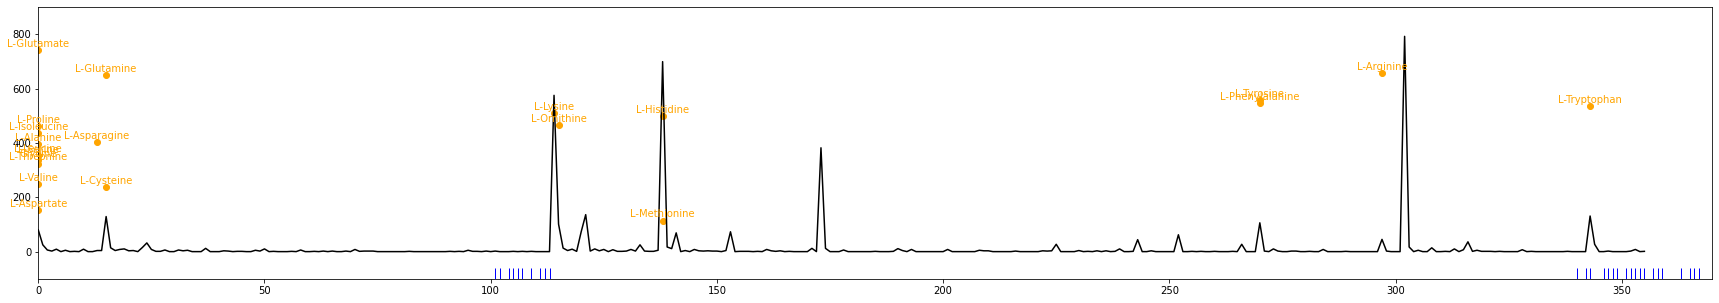

In [58]:
aa2iter = {}
for x in aa:
    aa2iter[x] = slowest.cpds_folditer[x]

plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFull.values(), color='k')

sns.rugplot(multiple, height=0.04, color='blue')  # double fold injection

# Add annotations
for key, value in aa2iter.items():
    position = random.randint(100, 800)
    plt.text(value, position, cpd2name[key], ha='center', va='bottom', color='orange')
    plt.scatter(value, position-5, color='orange')

plt.xlim([0, 370])
plt.ylim([-100, 900])
# plt.savefig('pro_pero_slowest_aa_annotated.svg', dpi=300, bbox_inches='tight')
plt.show()

## compare with before (fastest)

In [59]:
# fastest 'before' run
fastest_before = pd.read_pickle('../runs/2023-09-21_11-42-33_random_fold_ordering_42287-fixed-rn-seeds.pkl')
# file name is 'random' but it's actualy optimal

In [60]:
folditer2rns = {}
for rn, i in fastest_before.rns_folditer.items():
    if i not in folditer2rns.keys():
        folditer2rns[i] = []
    folditer2rns[i].append(rn)
    
folditer2folds = {}
for rn, i in fastest_before.folds_folditer.items():
    if i not in folditer2folds.keys():
        folditer2folds[i] = []
    folditer2folds[i].append(rn)
    
multiple = []
for i, folds in folditer2folds.items():
    if len(folds) > 1:
        multiple.append(i)

172


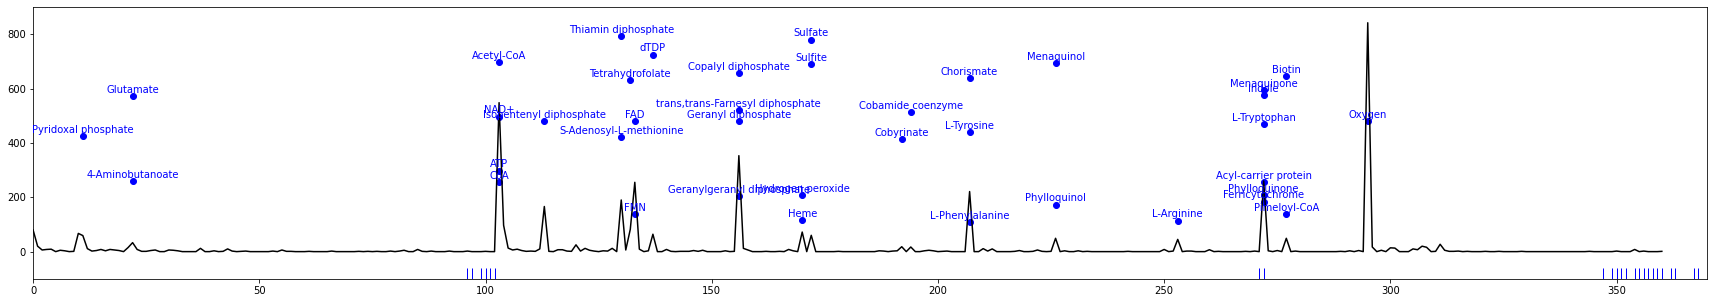

In [61]:
folditer2cpd = {}
for c, order in fastest_before.cpds_folditer.items():
    if order not in folditer2cpd.keys():
        folditer2cpd[order] = [c]
    else:
        folditer2cpd[order].append(c)
print(len(folditer2cpd))

folditer2cpdNum = {}
for fold in folditer2cpd.keys():
    folditer2cpdNum[fold] = len(folditer2cpd[fold])

folditer2cpdNumFull = {}
for i in range(0, max(folditer2cpd.keys())):
    if i not in folditer2cpdNum.keys():
        folditer2cpdNumFull[i] = 0
    else:
        folditer2cpdNumFull[i] = folditer2cpdNum[i]
        
cpd2iter = {}

for cpd in ['C0007', 'C00018', 'C00302', 'C00334', 'C11440', 'C00002', 'C00003', 'C00010', 'C00024', 'C00129', 'C00068', 'C00019', 'C00101', 'C00016', 'C00061', 'C00363', 'C00194', 'C00062', 'C00007', 'C00448', 'C11901', 'C00341', 'C00353', 'C00923', 'C00463', 'C00229', 'C05819', 'C03313', 'C00027', 'C00032', 'C00059', 'C00094', 'C05773', 'C00251', 'C00082', 'C00079', 'C00078', 'C02059', 'C00828', 'C01063', 'C00120']:
    for folditer in folditer2cpd.keys():
        for c in folditer2cpd[folditer]:
            if c == cpd:
                cpd2iter[c] = folditer
                
plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFull.values(), color='k')

sns.rugplot(multiple, height=0.04, color='blue')  # double fold injection

# Add annotations
for key, value in cpd2iter.items():
    position = random.randint(100, 800)
    plt.text(value, position, cpd2name[key], ha='center', va='bottom', color='blue')
    plt.scatter(value, position-5, color='b')

plt.xlim([0, 370])
plt.ylim([-100, 900])
# plt.savefig('pro_pero_fastest_before_cpd_annotated.svg', dpi=300, bbox_inches='tight')
plt.show()

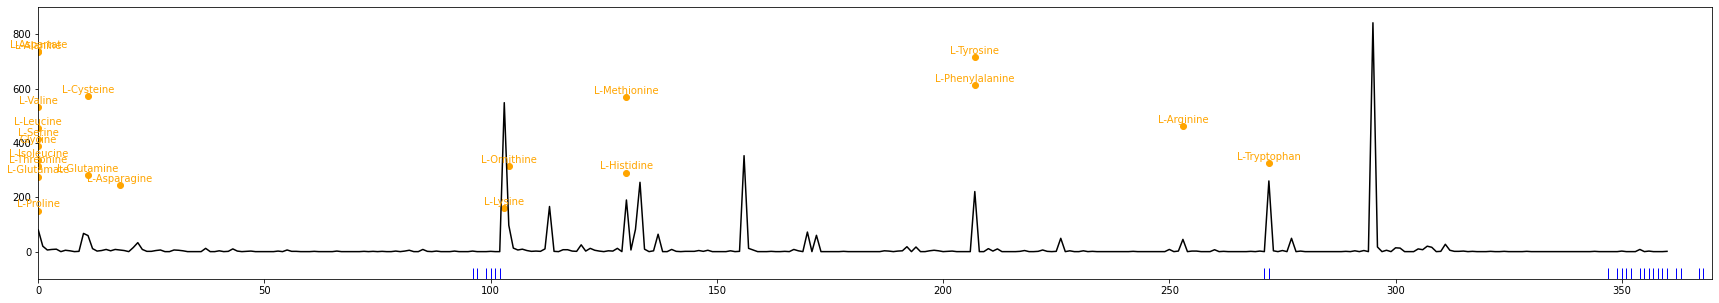

In [62]:
aa2iter = {}
for x in aa:
    aa2iter[x] = fastest_before.cpds_folditer[x]

plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFull.values(), color='k')

sns.rugplot(multiple, height=0.04, color='blue')  # double fold injection

# Add annotations
for key, value in aa2iter.items():
    position = random.randint(100, 800)
    plt.text(value, position, cpd2name[key], ha='center', va='bottom', color='orange')
    plt.scatter(value, position-5, color='orange')

plt.xlim([0, 370])
plt.ylim([-100, 900])
# plt.savefig('fold_gated_fastest_aa_annotated.svg', dpi=300, bbox_inches='tight')
plt.show()

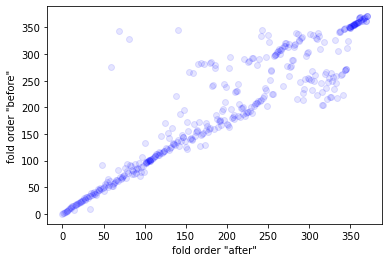

In [63]:
scatter(fastest.folds_folditer, fastest_before.folds_folditer, 'fold order "after"', 'fold order "before"')

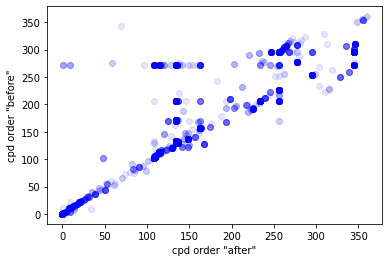

In [64]:
scatter(fastest.cpds_folditer, fastest_before.cpds_folditer, 'cpd order "after"', 'cpd order "before"')

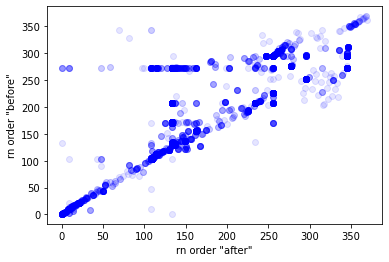

In [65]:
scatter(fastest.rns_folditer, fastest_before.rns_folditer, 'rn order "after"', 'rn order "before"')

### bokeh plots

In [66]:
# folds

output_file("annotated_plot.html")
p = figure(plot_width=800, plot_height=800, title="fastest fold order (before) vs. fastest fold order (after)")

# Add annotations
# source = {'x': list(group12iter.values()), 'y': y_values, 'label': ['X' + str(key) for key in group12iter.keys()]}
key, data1, data2 = todata(fastest.folds_folditer, fastest_before.folds_folditer)
source = {'x': data1, 'y': data2, 'label': [f"X{key} " + x2name.get(key, 'no X name') for key in key]}
p.scatter('x', 'y', source=source, size=10, color='blue')

# Add hover tool
hover = HoverTool()
hover.tooltips = [("folditer", "@x"), ("fold", "@label")]
p.add_tools(hover)

# Customize plot
p.xaxis.axis_label = 'fastest fold order (after)'
p.yaxis.axis_label = 'fastest fold order (before)'
p.xaxis.ticker = [50, 100, 150, 200, 250, 300, 350]  # Convert range to list
p.xgrid.grid_line_color = None

# Show the plot
show(p)

In [67]:
# cpds

output_file("annotated_plot.html")
p = figure(plot_width=800, plot_height=800, title="fastest cpd order (before) vs. fastest cpd order (after)")

# Add annotations
# source = {'x': list(group12iter.values()), 'y': y_values, 'label': ['X' + str(key) for key in group12iter.keys()]}
key, data1, data2 = todata(fastest.cpds_folditer, fastest_before.cpds_folditer)
source = {'x': data1, 'y': data2, 'label': [cpd2name.get(key, 'no name') for key in key]}
p.scatter('x', 'y', source=source, size=10, color='blue')

# Add hover tool
hover = HoverTool()
hover.tooltips = [("folditer", "@x"), ("cpd", "@label")]
p.add_tools(hover)

# Customize plot
p.xaxis.axis_label = 'fastest cpd order (after)'
p.yaxis.axis_label = 'fastest cpd order (before)'
p.xaxis.ticker = [50, 100, 150, 200, 250, 300, 350]  # Convert range to list
p.xgrid.grid_line_color = None

# Show the plot
show(p)

# variability of major peaks

In [68]:
def histo(c):
    print(cpd2name[c])
    print(np.mean(df_cpd.loc[c]), np.std(df_cpd.loc[c]))
    plt.hist(list(df_cpd.loc[c]), bins= 50, edgecolor='none')

    plt.xlabel('folditer')
    plt.ylabel('# runs')
    plt.xlim([0, 370])
    plt.show()

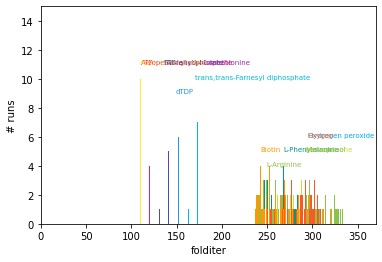

In [69]:
colors= ['#f44336', '#e81e63', '#9c27b0', '#673ab7', '#3f51b5', '#2196f3', '#03a9f4', '#00bcd4', '#009688', '#4caf50', '#8bc34a', '#cddc39', '#ffeb3b', '#ffc107', '#ff9800', '#ff5722']
i = 0

fig, ax = plt.subplots()
for c in ['C00002', 'C00129', 'C00019', 'C00101', 'C00016', 'C00363', 'C00027', 'C00448', 'C00079', 'C05819', 'C00062', 'C00828', 'C00229', 'C00078', 'C00120', 'C00007']:
#     plt.hist(list(df_optimal.loc[c]), bins= 100, edgecolor='none', alpha=1, color = colors[i])
#     i += 1
    
    counts, bins, patches = ax.hist(list(df_cpd.loc[c]), bins=100, edgecolor='none', alpha=1, color=colors[i])
    # Calculate the position for the annotation
    max_count = max(counts)
    max_bin = bins[counts.argmax()]

    ax.annotate(cpd2name[c], xy=(max_bin, max_count), xytext=(max_bin, max_count + 1),
                fontsize=7,
                color=colors[i],  # Set the text color here
                )
    i += 1

plt.xlabel('folditer')
plt.ylabel('# runs')
plt.xlim([0, 370])
plt.ylim([0, 15])
# plt.savefig('peak_variability_after.svg', dpi=300, bbox_inches='tight')
plt.show()

# adding alkane (alkene) to seed set

In [71]:
df_cpd_alkane = pd.read_csv('pro_pero/pro_pero_cpds_folditer_alkane.csv', index_col=0)
df_fold_alkane = pd.read_csv('pro_pero/pro_pero_folds_folditer_alkane.csv', index_col=0)
df_rn_alkane = pd.read_csv('pro_pero/pro_pero_rns_folditer_alkane.csv', index_col=0)

In [72]:
len(batm.cpds_folditer), len(batm.folds_folditer), len(batm.rns_folditer)

(4318, 399, 7708)

In [73]:
len(df_cpd), len(df_fold), len(df_rn)

(4294, 398, 7680)

In [74]:
len(df_cpd_alkane), len(df_fold_alkane), len(df_rn_alkane)

(4315, 399, 7707)

In [75]:
for c in set(batm.cpds_folditer) - set(df_cpd_alkane.index):
    print(c, cpd2name[c])

C19861 3-Hydroxy fatty acid
C22173 Harderoheme III
C05102 alpha-Hydroxy fatty acid


In [76]:
for rn in set(batm.rns_folditer) - set(df_rn_alkane.index):
    print(rn, rn2eqn_SI[rn])

RZ_268 C22173 => Z00025


In [77]:
# after + alkane
fo2cpds_list_alkane = []
for run in df_cpd_alkane.columns:  # 76 runs
    fo2cpds = {}
    for c, order in df_cpd_alkane[run].items():
        if order not in fo2cpds.keys():
            fo2cpds[order] = [c]
        else:
            fo2cpds[order].append(c)
    fo2cpds_list_alkane.append(fo2cpds)
    
fo2cpdNum_list_alkane = []
for run in fo2cpds_list_alkane:                   
    fo2cpdNum = {}
    cumm = 0
    for i in range(0, max(run.keys())): 
        if i in run.keys():
            cumm += len(run[i])
        fo2cpdNum[i] = cumm
    fo2cpdNum_list_alkane.append(fo2cpdNum)

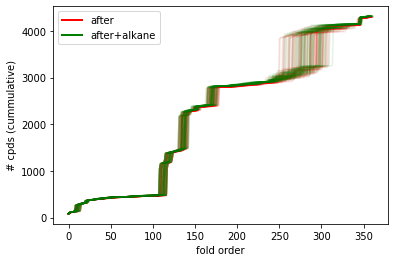

In [78]:
for run in fo2cpdNum_list:
    plt.plot(run.keys(), run.values(), color='red', alpha = 0.1,zorder=2)
for run in fo2cpdNum_list_alkane:
    plt.plot(run.keys(), run.values(), color='green', alpha = 0.1,zorder=2)
    
plt.xlabel('fold order')
plt.ylabel('# cpds (cummulative)')

# legend
custom_lines = [Line2D([0], [0], color='red', lw=2),
                Line2D([0], [0], color='green', lw=2)]
plt.legend(custom_lines, ['after', 'after+alkane'], loc='upper left')

# plt.savefig('fold_order_vs_cumm_cpds_alkane.png', dpi=300, bbox_inches = 'tight')
plt.show()

In [79]:
x2foAve_alkane = {}
for x in df_fold_alkane.index:
    x2foAve_alkane[x] = [np.mean(df_fold_alkane.loc[x]), np.std(df_fold_alkane.loc[x])]

In [80]:
x2foAve_alkane.pop('spontaneous')
x2foAve_alkane.pop('fold_independent')
x2foAve_alkane.pop('558')

[275.92105263157896, 32.63504862708139]

In [81]:
len(x2foAve_64), len(x2foAve_alkane)

(396, 396)

In [82]:
# for which folds did the averageFO change a lot?
# for 74 folds, average fold order changed by +/- 10 or more

plus10 = []
for x in x2foAve_alkane.keys():
    if x != '558':
        if abs(x2foAve_alkane[x][0] - x2foAve_64[x][0]) > 10:
            print(x, x2foAve_alkane[x], x2foAve_64[x], x in group1)
            plus10.append(x)
print(len(plus10))

7586 [158.6315789473684, 54.976751570972226] [177.75, 54.64773554320435] False
4044 [188.05263157894737, 90.31711598829543] [214.390625, 87.61663961320005] False
4017 [198.27631578947367, 99.41851975681952] [231.140625, 98.54105540133703] False
876 [274.0394736842105, 28.83639914261948] [285.5, 31.048852635806046] False
5103 [302.5263157894737, 24.34103838344797] [312.53125, 23.612740701525947] False
4029 [272.4605263157895, 28.166535196685974] [283.015625, 31.209219484943468] False
4049 [273.4605263157895, 28.166535196685974] [284.015625, 31.209219484943468] False
4111 [272.5131578947368, 30.59776970761648] [282.90625, 30.894335418285017] False
3339 [241.3815789473684, 128.1456785218398] [224.859375, 126.77118501303589] False
702 [241.3815789473684, 128.1456785218398] [224.859375, 126.77118501303589] False
7601 [237.94736842105263, 128.05137689479852] [208.953125, 125.27949124950331] False
7602 [237.94736842105263, 128.05137689479852] [208.953125, 125.27949124950331] False
12


## find fastest and annotate cpds, folds

In [83]:
max_area = [0, 0]
index = 0
for run in fo2cpdNum_list_alkane:
    area = sum(run.values())
    if area > max_area[1]:
        max_area = [index, area]
    index += 1
max_area

[58, 845175]

In [84]:
df_cpd_alkane.columns[58]

'2024-06-02_14-00-20'

In [85]:
fastest_alkane = pd.read_pickle('../10AAprotein_peroxide_Alkane/2024-06-02_14-00-20.pkl.gz')

In [86]:
folditer2rns = {}
for rn, i in fastest_alkane.rns_folditer.items():
    if i not in folditer2rns.keys():
        folditer2rns[i] = []
    folditer2rns[i].append(rn)
    
folditer2folds = {}
for rn, i in fastest_alkane.folds_folditer.items():
    if i not in folditer2folds.keys():
        folditer2folds[i] = []
    folditer2folds[i].append(rn)
    
multiple = []
for i, folds in folditer2folds.items():
    if len(folds) > 1:
        multiple.append(i)

172


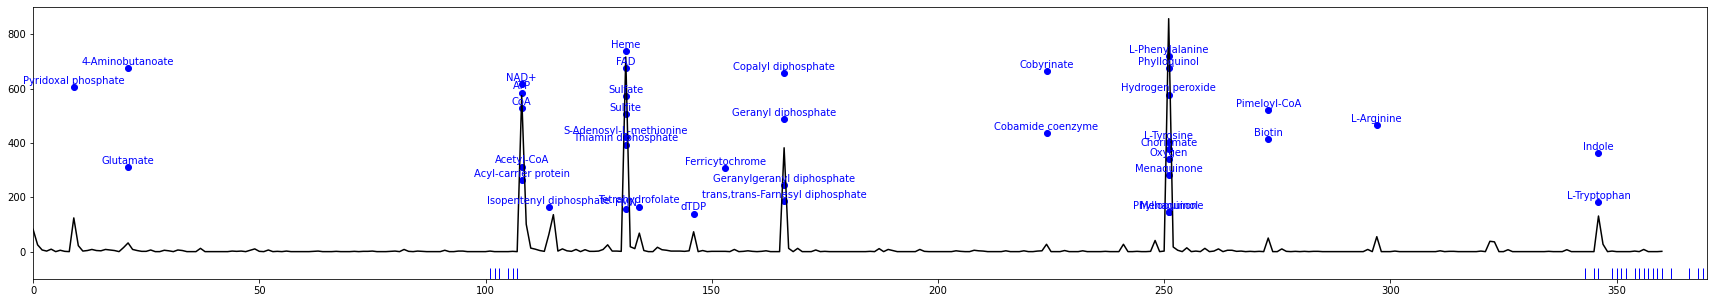

In [87]:
folditer2cpd = {}
for c, order in fastest_alkane.cpds_folditer.items():
    if order not in folditer2cpd.keys():
        folditer2cpd[order] = [c]
    else:
        folditer2cpd[order].append(c)
print(len(folditer2cpd))

folditer2cpdNum = {}
for fold in folditer2cpd.keys():
    folditer2cpdNum[fold] = len(folditer2cpd[fold])

folditer2cpdNumFull = {}
for i in range(0, max(folditer2cpd.keys())):
    if i not in folditer2cpdNum.keys():
        folditer2cpdNumFull[i] = 0
    else:
        folditer2cpdNumFull[i] = folditer2cpdNum[i]
        
cpd2iter = {}
for cpd in ['C0007', 'C00018', 'C00302', 'C00334', 'C11440', 'C00002', 'C00003', 'C00010', 'C00024', 'C00129', 'C00068', 'C00019', 'C00101', 'C00016', 'C00061', 'C00363', 'C00194', 'C00062', 'C00007', 'C00448', 'C11901', 'C00341', 'C00353', 'C00923', 'C00463', 'C00229', 'C05819', 'C03313', 'C00027', 'C00032', 'C00059', 'C00094', 'C05773', 'C00251', 'C00082', 'C00079', 'C00078', 'C02059', 'C00828', 'C01063', 'C00120']:
    for folditer in folditer2cpd.keys():
        for c in folditer2cpd[folditer]:
            if c == cpd:
                cpd2iter[c] = folditer
                
plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFull.values(), color='k')

sns.rugplot(multiple, height=0.04, color='blue')  # double fold injection

# Add annotations
for key, value in cpd2iter.items():
    position = random.randint(100, 800)
    plt.text(value, position, cpd2name[key], ha='center', va='bottom', color='blue')
    plt.scatter(value, position-5, color='b')

plt.xlim([0, 370])
plt.ylim([-100, 900])
# plt.savefig('pro_pero_alkane_fastest_cpd_annotated.svg', dpi=300, bbox_inches='tight')
plt.show()

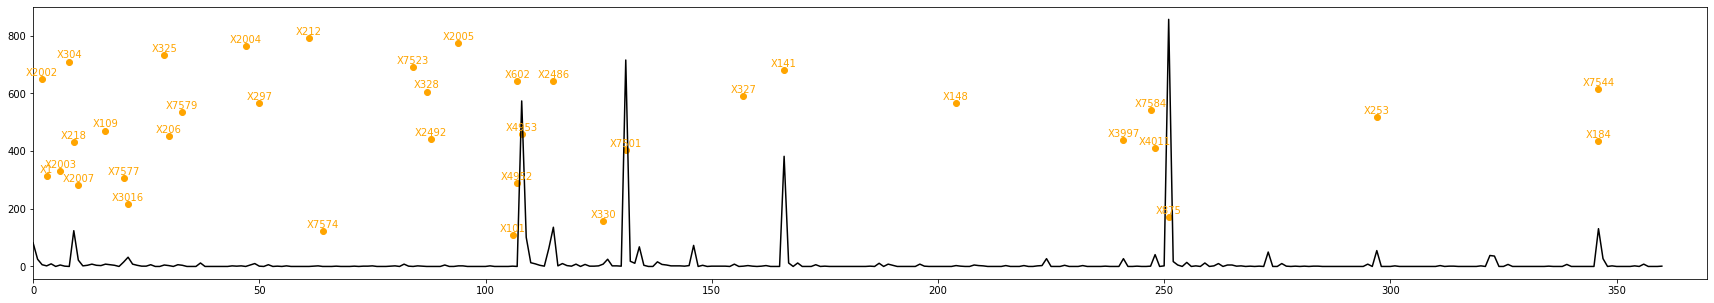

In [88]:
group12iter = {}
for x in group1:
    group12iter[x] = fastest_alkane.folds_folditer[x]

plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFull.values(), color='k')

# Add annotations
for key, value in group12iter.items():
    position = random.randint(100, 800)
    plt.text(value, position, 'X'+str(key), ha='center', va='bottom', color='orange')
    plt.scatter(value, position-5, color='orange')

plt.xlim([0, 370])
# plt.savefig('pro_pero_alkane_fastest_fold_annotated.svg', dpi=300, bbox_inches='tight')
plt.show()

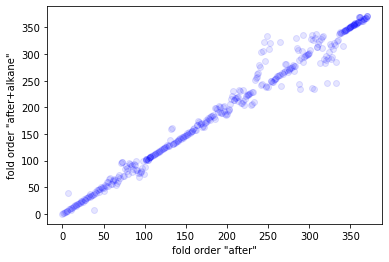

In [89]:
scatter(fastest.folds_folditer, fastest_alkane.folds_folditer, 'fold order "after"', 'fold order "after+alkane"')

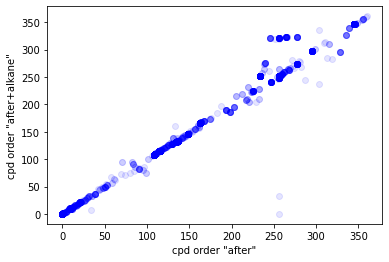

In [90]:
scatter(fastest.cpds_folditer, fastest_alkane.cpds_folditer, 'cpd order "after"', 'cpd order "after+alkane"')

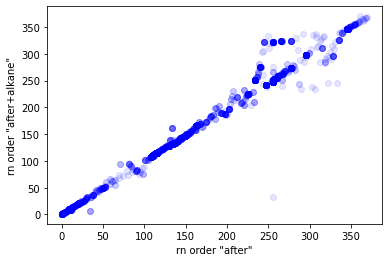

In [91]:
scatter(fastest.rns_folditer, fastest_alkane.rns_folditer, 'rn order "after"', 'rn order "after+alkane"')

In [92]:
# bokeh plots

In [93]:
# folds

output_file("annotated_plot.html")
p = figure(plot_width=800, plot_height=800, title="fastest fold order (after) vs. fastest fold order (after+alkane)")

# Add annotations
# source = {'x': list(group12iter.values()), 'y': y_values, 'label': ['X' + str(key) for key in group12iter.keys()]}
key, data1, data2 = todata(fastest.folds_folditer, fastest_alkane.folds_folditer)
source = {'x': data1, 'y': data2, 'label': [f"X{key} " + x2name.get(key, 'no X name') for key in key]}
p.scatter('x', 'y', source=source, size=10, color='blue')

# Add hover tool
hover = HoverTool()
hover.tooltips = [("folditer", "@x"), ("fold", "@label")]
p.add_tools(hover)

# Customize plot
p.xaxis.axis_label = 'fastest fold order (after)'
p.yaxis.axis_label = 'fastest fold order (after+alkane)'
p.xaxis.ticker = [50, 100, 150, 200, 250, 300, 350]  # Convert range to list
p.xgrid.grid_line_color = None

# Show the plot
show(p)

In [94]:
# cpds

output_file("annotated_plot.html")
p = figure(plot_width=800, plot_height=800, title="fastest cpd order (after) vs. fastest cpd order (after_alkane)")

# Add annotations
# source = {'x': list(group12iter.values()), 'y': y_values, 'label': ['X' + str(key) for key in group12iter.keys()]}
key, data1, data2 = todata(fastest.cpds_folditer, fastest_alkane.cpds_folditer)
source = {'x': data1, 'y': data2, 'label': [cpd2name.get(key, 'no name') for key in key]}
p.scatter('x', 'y', source=source, size=10, color='blue')

# Add hover tool
hover = HoverTool()
hover.tooltips = [("folditer", "@x"), ("cpd", "@label")]
p.add_tools(hover)

# Customize plot
p.xaxis.axis_label = 'fastest cpd order (after)'
p.yaxis.axis_label = 'fastest cpd order (after_alkane)'
p.xaxis.ticker = [50, 100, 150, 200, 250, 300, 350]  # Convert range to list
p.xgrid.grid_line_color = None

# Show the plot
show(p)

### compare after+alkane with before

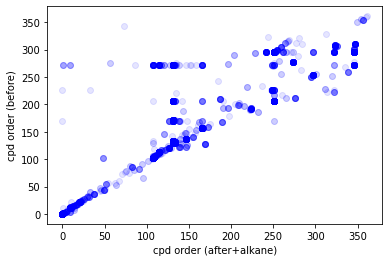

In [95]:
scatter(fastest_alkane.cpds_folditer, fastest_before.cpds_folditer, 'cpd order (after+alkane)', 'cpd order (before)')

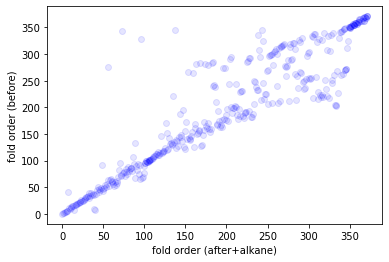

In [96]:
scatter(fastest_alkane.folds_folditer, fastest_before.folds_folditer, 'fold order (after+alkane)', 'fold order (before)')

In [97]:
# cpds

output_file("annotated_plot.html")
p = figure(plot_width=800, plot_height=800, title="cpd order (after+alkane) vs. cpd order (before)")

# Add annotations
# source = {'x': list(group12iter.values()), 'y': y_values, 'label': ['X' + str(key) for key in group12iter.keys()]}
key, data1, data2 = todata(fastest_alkane.cpds_folditer, fastest_before.cpds_folditer)
source = {'x': data1, 'y': data2, 'label': [cpd2name.get(key, 'no name') for key in key]}
p.scatter('x', 'y', source=source, size=10, color='blue')

# Add hover tool
hover = HoverTool()
hover.tooltips = [("folditer", "@x"), ("cpd", "@label")]
p.add_tools(hover)

# Customize plot
p.xaxis.axis_label = 'cpd order (after + alkane)'
p.yaxis.axis_label = 'cpd order (before)'
p.xaxis.ticker = [50, 100, 150, 200, 250, 300, 350]  # Convert range to list
p.xgrid.grid_line_color = None

# Show the plot
show(p)

In [98]:
{c:np.mean(df_cpd_alkane.loc[c]) for c in df_cpd_alkane.index}

{'C00288': 0.0,
 'C00048': 0.0,
 'C00150': 0.0,
 'C00080': 0.0,
 'C00282': 0.0,
 'C01371': 0.0,
 'C00183': 0.0,
 'C00283': 0.0,
 'C00161': 0.0,
 'C00417': 0.0,
 'C19806': 0.0,
 'C00037': 0.0,
 'C00001': 0.0,
 'C00009': 0.0,
 'Z00064': 0.0,
 'C14818': 0.0,
 'C00407': 0.0,
 'C00383': 0.0,
 'Z00062': 0.0,
 'C00041': 0.0,
 'C19609': 0.0,
 'C00065': 0.0,
 'C00160': 0.0,
 'Z00053': 0.0,
 'Z00069': 0.0,
 'Z00030': 0.0,
 'C00034': 0.0,
 'C17023': 0.0,
 'C00028': 0.0,
 'C00311': 0.0,
 'C00049': 0.0,
 'C00148': 0.0,
 'C00071': 0.0,
 'C00014': 0.0,
 'C00209': 0.0,
 'Z00033': 0.0,
 'C00070': 0.0,
 'C00188': 0.0,
 'C01372': 0.0,
 'Z00034': 0.0,
 'C00030': 0.0,
 'Z00001': 0.0,
 'C01732': 0.0,
 'C00149': 0.0,
 'Z00002': 0.0,
 'C22155': 0.0,
 'Z00054': 0.0,
 'Z00055': 0.0,
 'C00050': 0.0,
 'C00012': 0.0,
 'C00175': 0.0,
 'C20679': 0.0,
 'C00042': 0.0,
 'C00058': 0.0,
 'C00036': 0.0,
 'Z00006': 0.0,
 'Z00067': 0.0,
 'C06232': 0.0,
 'C01127': 0.0,
 'C00022': 0.0,
 'C00238': 0.0,
 'C00122': 0.0,
 'C00305

In [99]:
# cpds average
d1 = {c:np.mean(df_cpd_alkane.loc[c]) for c in df_cpd_alkane.index}
d2 = {c:np.mean(df_optimal.loc[c]) for c in df_optimal.index}

output_file("annotated_plot.html")
p = figure(plot_width=800, plot_height=800, title="ave. cpd order (after+alkane) vs. ave. cpd order (before)")

# Add annotations
# source = {'x': list(group12iter.values()), 'y': y_values, 'label': ['X' + str(key) for key in group12iter.keys()]}
key, data1, data2 = todata(d1, d2)
source = {'x': data1, 'y': data2, 'label': [cpd2name.get(key, 'no name') for key in key]}
p.scatter('x', 'y', source=source, size=10, color='blue')

# Add hover tool
hover = HoverTool()
hover.tooltips = [("folditer", "@x"), ("cpd", "@label")]
p.add_tools(hover)

# Customize plot
p.xaxis.axis_label = 'ave. cpd order (after + alkane)'
p.yaxis.axis_label = 'ave. cpd order (before)'
p.xaxis.ticker = [50, 100, 150, 200, 250, 300, 350]  # Convert range to list
p.xgrid.grid_line_color = None

# Show the plot
show(p)

## ELM: Ether Lipid Metabolism

In [100]:
elm = ['C03968', 'C02773', 'C05977', 'C03968', 'C03201', 'C20859', 'C20825', 'C05212', 'C04317', 'C04598', 'C03820', 'C03968', 'C04361', 'C01264', 'C04475', 'C04756', 'C03454', 'C00958', 'C04517', 'C00670', 'C15647', 'C15646', 'C15647', 'C04635', 'C15645', 'C01233'] 

for c in elm:
    print(c, c in df_cpd.index, c in batm.cpds_folditer.keys(), cpd2name[c])
len(elm)

C03968 False True 1-Alkyl-sn-glycero-3-phosphate
C02773 False True 1-Alkyl-sn-glycerol
C05977 False False 2-Acyl-1-alkyl-sn-glycero-3-phosphate
C03968 False True 1-Alkyl-sn-glycero-3-phosphate
C03201 False False 1-Alkyl-2-acylglycerol
C20859 False False Galactosyl-1-alkyl-2-acylglycerol
C20825 False False Seminolipid
C05212 False False 1-Radyl-2-acyl-sn-glycero-3-phosphocholine
C04317 False True 1-Organyl-2-lyso-sn-glycero-3-phosphocholine
C04598 False True 2-Acetyl-1-alkyl-sn-glycero-3-phosphocholine
C03820 False True 1-Alkyl-2-acetyl-sn-glycerol
C03968 False True 1-Alkyl-sn-glycero-3-phosphate
C04361 False False 1-O-Alkyl-2-acetyl-3-acyl-sn-glycerol
C01264 False True 2-Acetyl-1-alkyl-sn-glycero-3-phosphate
C04475 False False 1-Alkyl-2-acylglycerophosphoethanolamine
C04756 False False O-1-Alk-1-enyl-2-acyl-sn-glycero-3-phosphoethanolamine
C03454 False False 1-Alkenyl-2-acylglycerol
C00958 False False Plasmenylcholine
C04517 False False 1-(1-Alkenyl)-sn-glycero-3-phosphocholine
C00670 

26

In [101]:
for c in set(batm.cpds_folditer) - set(df_cpd.index):
    if c not in elm:
        print(c, cpd2name[c])

C00638 Long-chain fatty acid
C19861 3-Hydroxy fatty acid
C05102 alpha-Hydroxy fatty acid
C04476 1-Alkyl-sn-glycero-3-phosphoethanolamine
C04080 N-(Long-chain-acyl)ethanolamine
C03715 O-Alkylglycerone phosphate
C21886 omega-Hydroxy-long-chain fatty acid
C22173 Harderoheme III
C00609 Long-chain aldehyde
C21763 Long-chain alkane
C03129 Long-chain acid anion
C04305 N-Long-chain-fatty-acyl-L-glutamate
C00339 Long-chain alcohol
C00347 Long-chain carboxylate
C04202 Long-chain-fatty-acyl ethyl ester
C01371 Alkane
C02446 O-Alkylglycerone
C20683 Long-chain acyl-[acyl-carrier protein]


# pre-expansion to ATP

In [103]:
df_cpd_preATP = pd.read_csv('pro_pero/pro_pero_cpds_folditer_preATP.csv', index_col=0)
df_fold_preATP = pd.read_csv('pro_pero/pro_pero_folds_folditer_preATP.csv', index_col=0)
df_rn_preATP = pd.read_csv('pro_pero/pro_pero_rns_folditer_preATP.csv', index_col=0)

In [104]:
len(batm.cpds_folditer), len(batm.folds_folditer), len(batm.rns_folditer)

(4318, 399, 7708)

In [105]:
len(df_cpd), len(df_fold), len(df_rn)  # NONE

(4294, 398, 7680)

In [106]:
len(df_cpd_preATP), len(df_fold_preATP), len(df_rn_preATP)

(4291, 398, 7680)

In [107]:
for c in set(df_cpd.index) - set(df_cpd_preATP.index):  # must be somehow missing from the seed
    print(c, cpd2name[c])

C00050 Metal
Z00020 Generic FeS Cluster
C00034 Manganese


In [108]:
preATP1 = pd.read_pickle('../10AAprotein_preATP/2024-05-31_12-32-02_protein_peroxide_preATP.pkl.gz')

In [109]:
folditer2rns = {}
for rn, i in preATP1.rns_folditer.items():
    if i not in folditer2rns.keys():
        folditer2rns[i] = []
    folditer2rns[i].append(rn)
    
folditer2folds = {}
for rn, i in preATP1.folds_folditer.items():
    if i not in folditer2folds.keys():
        folditer2folds[i] = []
    folditer2folds[i].append(rn)
    
multiple = []
for i, folds in folditer2folds.items():
    if len(folds) > 1:
        multiple.append(i)

167


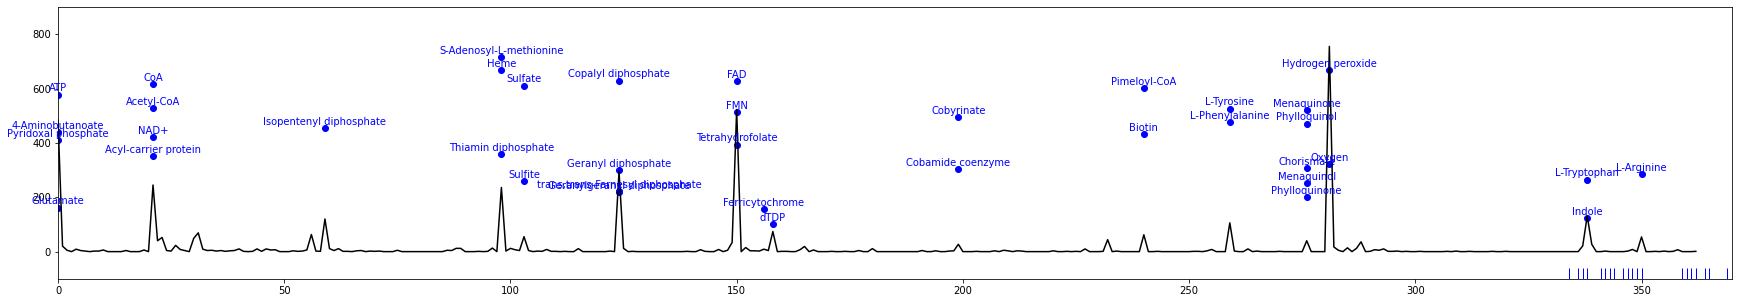

In [110]:
folditer2cpd = {}
for c, order in preATP1.cpds_folditer.items():
    if order not in folditer2cpd.keys():
        folditer2cpd[order] = [c]
    else:
        folditer2cpd[order].append(c)
print(len(folditer2cpd))

folditer2cpdNum = {}
for fold in folditer2cpd.keys():
    folditer2cpdNum[fold] = len(folditer2cpd[fold])

folditer2cpdNumFull = {}
for i in range(0, max(folditer2cpd.keys())):
    if i not in folditer2cpdNum.keys():
        folditer2cpdNumFull[i] = 0
    else:
        folditer2cpdNumFull[i] = folditer2cpdNum[i]
        
cpd2iter = {}

for cpd in ['C0007', 'C00018', 'C00302', 'C00334', 'C11440', 'C00002', 'C00003', 'C00010', 'C00024', 'C00129', 'C00068', 'C00019', 'C00101', 'C00016', 'C00061', 'C00363', 'C00194', 'C00062', 'C00007', 'C00448', 'C11901', 'C00341', 'C00353', 'C00923', 'C00463', 'C00229', 'C05819', 'C03313', 'C00027', 'C00032', 'C00059', 'C00094', 'C05773', 'C00251', 'C00082', 'C00079', 'C00078', 'C02059', 'C00828', 'C01063', 'C00120']:
    for folditer in folditer2cpd.keys():
        for c in folditer2cpd[folditer]:
            if c == cpd:
                cpd2iter[c] = folditer
                
plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFull.values(), color='k')

sns.rugplot(multiple, height=0.04, color='blue')  # double fold injection

# Add annotations
for key, value in cpd2iter.items():
    position = random.randint(100, 800)
    plt.text(value, position, cpd2name[key], ha='center', va='bottom', color='blue')
    plt.scatter(value, position-5, color='b')

plt.xlim([0, 370])
plt.ylim([-100, 900])
# plt.savefig('pro_pero_preATP1_cpd_annotated.svg', dpi=300, bbox_inches='tight')
plt.show()

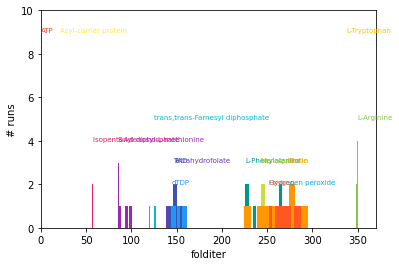

In [111]:
colors= ['#f44336', '#e81e63', '#9c27b0', '#673ab7', '#3f51b5', '#2196f3', '#03a9f4', '#00bcd4', '#009688', '#4caf50', '#8bc34a', '#cddc39', '#ffeb3b', '#ffc107', '#ff9800', '#ff5722']
i = 0

fig, ax = plt.subplots()
for c in ['C00002', 'C00129', 'C00019', 'C00101', 'C00016', 'C00363', 'C00027', 'C00448', 'C00079', 'C05819', 'C00062', 'C00828', 'C00229', 'C00078', 'C00120', 'C00007']:
#     plt.hist(list(df_optimal.loc[c]), bins= 100, edgecolor='none', alpha=1, color = colors[i])
#     i += 1
    
    counts, bins, patches = ax.hist(list(df_cpd_preATP.loc[c]), edgecolor='none', alpha=1, color=colors[i])
    # Calculate the position for the annotation
    max_count = max(counts)
    max_bin = bins[counts.argmax()]

    ax.annotate(cpd2name[c], xy=(max_bin, max_count), xytext=(max_bin, max_count + 1),
                fontsize=7,
                color=colors[i],  # Set the text color here
                )
    i += 1

plt.xlabel('folditer')
plt.ylabel('# runs')
plt.xlim([0, 370])
plt.ylim([0, 10])
# plt.savefig('peak_variability_after_preATP.svg', dpi=300, bbox_inches='tight')
plt.show()

# pre-expansion to ATP with alkane

In [113]:
df_cpd_preATP_alkane = pd.read_csv('pro_pero/pro_pero_cpds_folditer_preATP_alkane.csv', index_col=0)
df_fold_preATP_alkane = pd.read_csv('pro_pero/pro_pero_folds_folditer_preATP_alkane.csv', index_col=0)
df_rn_preATP_alkane = pd.read_csv('pro_pero/pro_pero_rns_folditer_preATP_alkane.csv', index_col=0)

In [114]:
len(batm.cpds_folditer), len(batm.folds_folditer), len(batm.rns_folditer)

(4318, 399, 7708)

In [115]:
len(df_cpd_preATP_alkane), len(df_fold_preATP_alkane), len(df_rn_preATP_alkane)

(4312, 399, 7707)

In [116]:
for c in set(batm.cpds_folditer.keys()) - set(df_cpd_preATP_alkane.index):
    print(c, cpd2name[c])

C00050 Metal
C19861 3-Hydroxy fatty acid
C22173 Harderoheme III
C00034 Manganese
C05102 alpha-Hydroxy fatty acid
Z00020 Generic FeS Cluster


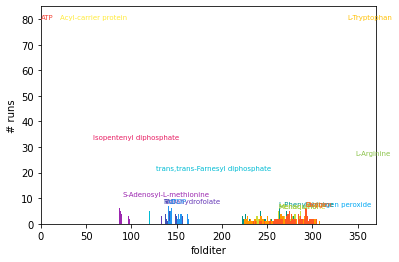

In [117]:
colors= ['#f44336', '#e81e63', '#9c27b0', '#673ab7', '#3f51b5', '#2196f3', '#03a9f4', '#00bcd4', '#009688', '#4caf50', '#8bc34a', '#cddc39', '#ffeb3b', '#ffc107', '#ff9800', '#ff5722']
i = 0

fig, ax = plt.subplots()
for c in ['C00002', 'C00129', 'C00019', 'C00101', 'C00016', 'C00363', 'C00027', 'C00448', 'C00079', 'C05819', 'C00062', 'C00828', 'C00229', 'C00078', 'C00120', 'C00007']:
#     plt.hist(list(df_optimal.loc[c]), bins= 100, edgecolor='none', alpha=1, color = colors[i])
#     i += 1
    
    counts, bins, patches = ax.hist(list(df_cpd_preATP_alkane.loc[c]), bins=50, edgecolor='none', alpha=1, color=colors[i])
    # Calculate the position for the annotation
    max_count = max(counts)
    max_bin = bins[counts.argmax()]

    ax.annotate(cpd2name[c], xy=(max_bin, max_count), xytext=(max_bin, max_count + 1),
                fontsize=7,
                color=colors[i],  # Set the text color here
                )
    i += 1

plt.xlabel('folditer')
plt.ylabel('# runs')
plt.xlim([0, 370])
plt.ylim([0, 85])
# plt.savefig('peak_variability_after_preATP_alkane.svg', dpi=300, bbox_inches='tight')
plt.show()

# PCA of pro-pero

In [118]:
from sklearn.decomposition import PCA

df_original = pd.read_csv('../fold_iters_pre_expansion.csv', index_col=0)

In [119]:
# transpose df_fold
df_fold_T = df_fold.T

In [120]:
# Step 1: Add missing columns to 'new' DataFrame with NaN values
for col in df_original.columns:
    if col not in df_fold_T.columns:
        df_fold_T[col] = pd.NA

In [121]:
# Step 2: Reorder the columns of 'new' to match the order of 'original'
df_fold_T = df_fold_T[df_original.columns]

In [122]:
# Step 2.5: set pre-expansion label to 'pro_pero'
df_fold_T['PreExpansion_Label'] = 'pro_pero'

In [123]:
# Step 3: Append 'new' DataFrame to 'original' DataFrame
combined = pd.concat([df_original, df_fold_T], ignore_index=False)

In [124]:
# Step 4: drop '558'
combined = combined.drop('558', axis=1)

In [125]:
# Step 5: save as new csv
combined.to_csv('../fold_iters_pre_expansion_propero.csv')

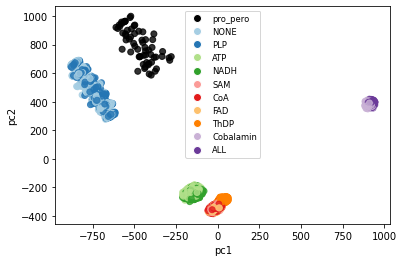

In [126]:
# color by pre label

data_path = '../fold_iters_pre_expansion_propero.csv'
with open(data_path, 'r') as file:
    lines = file.readlines()

data = []  # 10,064 * 397
labels = []  # 10,064
for line in lines:
    if line[0] == ',':
        continue
    fo = line.split(',')[3:-3]
    pre = line.split(',')[-1].strip()  # pre-expansion labels
    data.append(fo)
    labels.append(pre)
np.array(data)
df = pd.DataFrame(data, index=labels)

label_colors = {'pro_pero': '#000000', 'NONE': '#A6CEE3', 'C00002': '#B1E08A', 'C00004': '#31A12C', 'C00010': '#E21C1C', 'C00016': '#FDC16E', 'C00019': '#FB9B98', 'Z00009': '#CAB2D6', 'Z00035': '#2576B4', 'Z00047': '#FF8000', 'ALL': '#6B3A99'}
label_colors2 = {'pro_pero': 'pro_pero', 'NONE': 'NONE', 'Z00035': 'PLP', 'C00002': 'ATP', 'C00004': 'NADH', 'C00019': 'SAM', 'C00010': 'CoA', 'C00016': 'FAD', 'Z00047': 'ThDP', 'Z00009': 'Cobalamin', 'ALL': 'ALL'}
# Map index values to their corresponding colors
colors_by_label = df.index.map(label_colors)

pca = PCA(n_components=2)
principal_components = pca.fit_transform(data)

# Create a scatter plot with colored points based on the index labels
plt.scatter(principal_components[:, 0], principal_components[:, 1], c=colors_by_label, alpha=0.8)
    
plt.xlabel('pc1')
plt.ylabel('pc2')
legend_labels = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=label_colors[label], markersize=8, label=label_colors2[label]) for label in label_colors2.keys()]
plt.legend(handles=legend_labels, loc="upper center", fontsize='small')
# plt.savefig('PCA.png')
plt.show()

# Why the zone of uncertainty? (oxygen, arginine etc.)

In [127]:
x2rulesNum = csv2dict('../data/assets/xgroup2/xgroup2rulesNum.csv')

In [128]:
folditer2rules_slowest = {}
for rule, i in slowest.rules_folditer.items():
    if i not in folditer2rules_slowest.keys():
        folditer2rules_slowest[i] = [rule]
    else:
        folditer2rules_slowest[i].append(rule)

In [129]:
folditer2rulesNum_slowest = {key:len(values) for key, values in folditer2rules_slowest.items()}

In [130]:
folditer2rules_fastest = {}
for rule, i in fastest.rules_folditer.items():
    if i not in folditer2rules_fastest.keys():
        folditer2rules_fastest[i] = [rule]
    else:
        folditer2rules_fastest[i].append(rule)

In [131]:
folditer2rulesNum_fastest = {key:len(values) for key, values in folditer2rules_fastest.items()}

In [132]:
fastest.cpds_folditer['C00007']

256

In [134]:
fastest.folds_folditer

{'fold_independent': 0,
 'spontaneous': 1,
 '2002': 2,
 '1': 3,
 '2487': 4,
 '2006': 5,
 '2003': 6,
 '7518': 7,
 '218': 8,
 '2007': 9,
 '7525': 10,
 '304': 11,
 '12': 12,
 '11': 13,
 '246': 14,
 '109': 15,
 '10': 16,
 '210': 17,
 '7515': 18,
 '279': 19,
 '7577': 20,
 '3016': 21,
 '281': 22,
 '7528': 23,
 '331': 24,
 '7542': 25,
 '301': 26,
 '2011': 27,
 '7572': 28,
 '325': 29,
 '206': 30,
 '282': 31,
 '7527': 32,
 '805': 33,
 '62': 34,
 '7579': 35,
 '7512': 36,
 '7529': 37,
 '7560': 38,
 '4126': 39,
 '3691': 40,
 '180': 41,
 '315': 42,
 '4002': 43,
 '70': 44,
 '286': 45,
 '2004': 46,
 '297': 47,
 '2485': 48,
 '7580': 49,
 '205': 50,
 '7554': 51,
 '5': 52,
 '7561': 53,
 '7517': 54,
 '387': 55,
 '2': 56,
 '7571': 57,
 '307': 58,
 '3156': 59,
 '208': 60,
 '247': 61,
 '7567': 62,
 '7516': 63,
 '7574': 64,
 '7510': 65,
 '5104': 66,
 '212': 67,
 '103': 68,
 '132': 69,
 '3651': 70,
 '810': 71,
 '2498': 72,
 '4081': 73,
 '4021': 74,
 '298': 75,
 '7523': 76,
 '3847': 77,
 '328': 78,
 '7573': 79

In [135]:
folditer2rulesNum_fastest

{1: 3,
 2: 9,
 3: 14,
 4: 8,
 5: 6,
 6: 11,
 7: 4,
 8: 16,
 9: 152,
 10: 21,
 11: 24,
 12: 19,
 13: 18,
 14: 17,
 15: 16,
 16: 13,
 17: 14,
 18: 11,
 19: 10,
 20: 21,
 21: 66,
 22: 10,
 23: 9,
 24: 10,
 25: 8,
 26: 6,
 27: 10,
 28: 6,
 29: 16,
 30: 12,
 31: 9,
 32: 5,
 33: 5,
 34: 4,
 35: 4,
 36: 4,
 37: 4,
 38: 14,
 39: 4,
 40: 4,
 41: 4,
 42: 3,
 43: 3,
 44: 3,
 45: 3,
 46: 3,
 47: 3,
 48: 5,
 49: 3,
 50: 11,
 51: 3,
 52: 2,
 53: 25,
 54: 2,
 55: 2,
 56: 2,
 57: 2,
 58: 2,
 59: 2,
 60: 2,
 61: 2,
 62: 2,
 63: 2,
 64: 2,
 65: 2,
 66: 2,
 67: 2,
 68: 1,
 69: 1,
 70: 1,
 71: 3,
 72: 1,
 73: 6,
 74: 1,
 75: 8,
 76: 1,
 77: 1,
 78: 1,
 79: 1,
 80: 1,
 81: 1,
 82: 5,
 83: 1,
 84: 5,
 85: 1,
 86: 2,
 87: 1,
 88: 1,
 89: 1,
 90: 8,
 91: 6,
 92: 1,
 93: 1,
 94: 1,
 95: 2,
 96: 1,
 97: 1,
 98: 1,
 99: 3,
 100: 1,
 101: 8,
 102: 6,
 103: 3,
 104: 6,
 105: 2,
 106: 2,
 107: 1,
 108: 1260,
 109: 190,
 110: 53,
 111: 38,
 112: 33,
 113: 24,
 114: 67,
 115: 210,
 116: 18,
 117: 23,
 118: 18,
 119: 

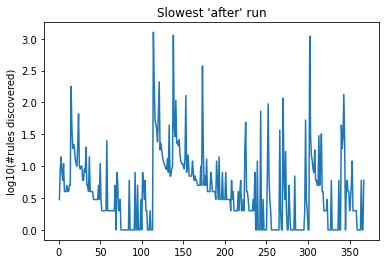

In [136]:
plt.plot(folditer2rulesNum_slowest.keys(), np.log10(list(folditer2rulesNum_slowest.values())))
plt.title("Slowest 'after' run")
plt.ylabel('log10(#rules discovered)')
plt.show()

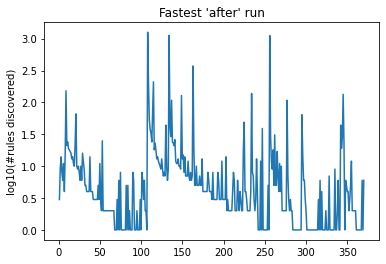

In [137]:
plt.plot(folditer2rulesNum_fastest.keys(), np.log10(list(folditer2rulesNum_fastest.values())))
plt.title("Fastest 'after' run")
plt.ylabel('log10(#rules discovered)')
plt.show()

## (std of foAVE) oc 1/(new rule added) ?

In [140]:
fold2fo_list = []
for run in df_fold.columns:  # 64 runs
    fold2fo = {}
    for fold, order in df_fold[run].items():
        fold2fo[fold] = order
    fold2fo_list.append(fold2fo)

In [142]:
df_rule = pd.read_csv('pro_pero/pro_pero_rules_folditer.csv', index_col=0)

In [143]:
df_rule.head()

,2024-05-30_12-50-25,2024-05-30_09-49-49,2024-05-30_04-22-27,2024-05-30_14-02-36,2024-05-31_01-27-23,2024-05-30_23-03-20,2024-05-30_03-09-15,2024-05-30_20-39-02,2024-05-30_22-27-11,2024-05-30_09-13-53,...,2024-05-31_07-27-59,2024-05-30_19-27-02,2024-05-30_13-26-24,2024-05-31_05-03-59,2024-05-31_11-38-33,2024-05-31_11-02-16,2024-05-31_09-14-54,2024-05-30_21-51-15,2024-05-30_11-02-28,2024-05-30_06-11-54
"('R08698', frozenset({'spontaneous'}))",1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
"('R12185', frozenset({'spontaneous'}))",1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
"('R07316', frozenset({'spontaneous'}))",1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
"('R00470_v1', frozenset({'2002'}))",2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
"('R00217_v1', frozenset({'2002'}))",2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2


In [144]:
fo2rules_list = []
for run in df_rule.columns:  # 64 runs
    fo2rules = {}
    for c, order in df_rule[run].items():
        if order not in fo2rules.keys():
            fo2rules[order] = [c]
        else:
            fo2rules[order].append(c)
    fo2rules_list.append(fo2rules)
    
fo2ruleNum_list = []  # NOT cummulative
for run in fo2rules_list:                   
    fo2ruleNum = {key:len(values) for key, values in run.items()}
    fo2ruleNum_list.append(fo2ruleNum)

In [145]:
fo2ruleNum_list[0]

{1: 3,
 2: 9,
 3: 14,
 4: 8,
 5: 6,
 6: 11,
 7: 4,
 8: 4,
 9: 5,
 10: 5,
 11: 76,
 12: 100,
 13: 21,
 14: 24,
 15: 19,
 16: 22,
 17: 19,
 18: 13,
 19: 14,
 20: 11,
 21: 10,
 22: 21,
 23: 66,
 24: 10,
 25: 9,
 26: 10,
 27: 6,
 28: 6,
 29: 10,
 30: 8,
 31: 20,
 32: 9,
 33: 5,
 34: 5,
 35: 4,
 36: 4,
 37: 14,
 38: 4,
 39: 4,
 40: 4,
 41: 4,
 42: 3,
 43: 3,
 44: 3,
 45: 3,
 46: 5,
 47: 3,
 48: 3,
 49: 11,
 50: 3,
 51: 3,
 52: 2,
 53: 2,
 54: 2,
 55: 2,
 56: 2,
 57: 2,
 58: 2,
 59: 2,
 60: 2,
 61: 25,
 62: 2,
 63: 2,
 64: 2,
 65: 2,
 66: 2,
 67: 2,
 68: 1,
 69: 2,
 70: 1,
 71: 2,
 72: 1,
 73: 5,
 74: 1,
 75: 6,
 76: 1,
 77: 3,
 78: 1,
 79: 1,
 80: 1,
 81: 1,
 82: 1,
 83: 1,
 84: 1,
 85: 5,
 86: 1,
 87: 1,
 88: 8,
 89: 6,
 90: 3,
 91: 1,
 92: 1,
 93: 1,
 94: 1,
 95: 8,
 96: 1,
 97: 1,
 98: 1,
 99: 1,
 100: 1,
 101: 8,
 102: 6,
 103: 3,
 104: 6,
 105: 2,
 106: 2,
 107: 1,
 108: 1,
 109: 1,
 110: 1,
 111: 1,
 112: 2,
 113: 1,
 114: 1262,
 115: 190,
 116: 53,
 117: 45,
 118: 38,
 119: 24,
 120:

In [146]:
import collections

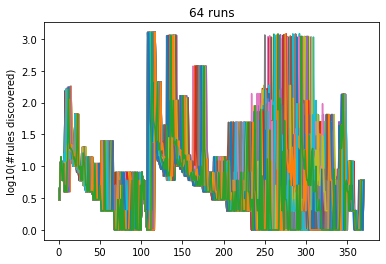

In [147]:
for run in fo2ruleNum_list:
    run2 = collections.OrderedDict(sorted(run.items()))
    plt.plot(run2.keys(), np.log10(list(run2.values())), alpha=1)
plt.title("64 runs")
plt.ylabel('log10(#rules discovered)')
plt.show()

In [148]:
fold2rulesNum_list = []  # list of 64 dicts
for i in range(0,63):
    fold2rulesNum = {}
    
    for fold in fold2fo_list[i].keys():
        if fold != 'fold_independent':
            fo = fold2fo_list[i][fold]
            fold2rulesNum[fold] = fo2ruleNum_list[i][fo]  # connect fold with # new rules
    
    fold2rulesNum_list.append(fold2rulesNum)

In [149]:
fold2rulesNum_list[0].keys()

dict_keys(['spontaneous', '2002', '1', '2487', '2006', '2003', '7518', '4126', '7542', '246', '218', '2007', '7525', '304', '12', '11', '109', '10', '210', '7515', '279', '7577', '3016', '281', '7528', '331', '301', '7572', '2011', '206', '325', '282', '7527', '805', '180', '7512', '7560', '7529', '3691', '7579', '62', '315', '7554', '70', '4002', '2485', '2004', '297', '205', '7580', '286', '208', '247', '7567', '7510', '3156', '2', '307', '212', '387', '7561', '5104', '7571', '5', '7516', '7517', '7574', '911', '611', '132', '283', '3651', '2005', '2498', '4081', '7573', '632', '103', '328', '64', '708', '302', '2484', '7520', '185', '221', '2492', '7543', '211', '810', '285', '2493', '7523', '4021', '298', '7541', '7552', '164', '3847', '149', '4020', '4045', '355', '4178', '108', '4018', '7587', '7546', '7507', '812', '101', '4019', '223', '3339', '702', '7601', '7602', '144', '3374', '278', '604', '7588', '602', '4952', '4953', '7524', '236', '131', '129', '159', '7581', '2486', '

In [150]:
fold2rulesNum_64runs = {key:[] for key in fold2rulesNum_list[0].keys()}  # empty dict

for run in fold2rulesNum_list:
    for fold, num in run.items():
        fold2rulesNum_64runs[fold].append(num)

In [151]:
fold2rulesNum_64runs['253']

[53,
 64,
 64,
 64,
 51,
 52,
 64,
 52,
 51,
 52,
 52,
 65,
 51,
 64,
 64,
 52,
 64,
 51,
 65,
 51,
 52,
 52,
 52,
 52,
 65,
 52,
 53,
 64,
 51,
 51,
 65,
 52,
 65,
 51,
 64,
 64,
 64,
 65,
 51,
 51,
 65,
 51,
 65,
 51,
 51,
 64,
 64,
 52,
 65,
 52,
 52,
 51,
 51,
 52,
 52,
 65,
 51,
 52,
 52,
 64,
 52,
 65,
 52]

In [152]:
fold2rulesNum_64runs['7584']

[1,
 1,
 1,
 73,
 103,
 74,
 1081,
 72,
 1,
 72,
 1,
 1,
 73,
 72,
 1,
 1,
 1,
 1,
 72,
 74,
 74,
 1,
 72,
 1,
 79,
 1,
 1,
 1,
 107,
 76,
 78,
 72,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 79,
 1,
 1,
 1,
 1133,
 79,
 1062,
 1,
 1,
 107,
 1,
 78,
 1118,
 1,
 1,
 1,
 72,
 1,
 72,
 1,
 1,
 72,
 1,
 78]

In [153]:
fold2rulesNum_64runs['3997']

[1066,
 1020,
 37,
 37,
 1056,
 1066,
 37,
 37,
 37,
 37,
 37,
 37,
 37,
 1033,
 39,
 1075,
 39,
 1057,
 995,
 37,
 37,
 1057,
 37,
 1055,
 1053,
 1057,
 37,
 37,
 1064,
 37,
 37,
 37,
 37,
 1087,
 39,
 1075,
 37,
 37,
 37,
 1066,
 37,
 37,
 37,
 39,
 39,
 37,
 1044,
 1047,
 1043,
 1021,
 1066,
 37,
 37,
 37,
 37,
 37,
 39,
 39,
 1054,
 37,
 37,
 37,
 37]

## define 'singleton' folds:
- x2rulesNum = 1
- x2rulesNum > 1, but its injection **may** result in only 1 rule addition 

In [154]:
# it's just X3997(1), X253(1), X875(2) = chorismate (gates Phe/Tyr and O2)

singleton1 = set()
lowRule = set()
for x, num in x2rulesNum.items():
    if num == 1.0:
        singleton1.add(x)
    if num < 6.0:
        lowRule.add(x)

In [155]:
# no '0' => df_rule records rule addition, not rn addition
# if '0' exists, that's an 'alternative rule' addition (new rule addition of old reaction)

for x, nums in fold2rulesNum_64runs.items():
    if 0 in nums:
        print(x, nums.count(1)/len(nums), x in singleton1)

In [156]:
import copy

In [157]:
singleton2 = copy.deepcopy(singleton1)
count = 0
for x, nums in fold2rulesNum_64runs.items():
    if 1 in nums:
        print(x, nums.count(1)/len(nums), x in singleton1)
        singleton2.add(x)
        if nums.count(1)/len(nums) == 1.0:
            count+=1

911 1.0 False
132 1.0 False
3651 1.0 False
2498 1.0 False
7573 1.0 False
103 1.0 False
328 1.0 False
64 1.0 False
708 1.0 False
302 1.0 False
2484 1.0 False
7520 1.0 False
221 1.0 False
2492 1.0 False
285 1.0 False
2493 1.0 False
7523 1.0 False
4021 1.0 False
7541 1.0 False
7552 1.0 False
164 1.0 False
3847 1.0 False
149 1.0 False
4019 0.5396825396825397 False
223 0.5396825396825397 False
3339 1.0 False
702 1.0 False
7601 1.0 False
7602 1.0 False
144 1.0 False
3374 1.0 False
278 0.47619047619047616 False
604 0.47619047619047616 False
602 1.0 False
4952 1.0 False
7586 0.3968253968253968 False
633 0.7142857142857143 False
4161 1.0 False
268 0.6825396825396826 False
5067 1.0 True
9 0.7142857142857143 False
3447 0.5396825396825397 False
4029 1.0 False
7584 0.5555555555555556 False
4011 0.38095238095238093 False
4237 1.0 True
4111 1.0 True
608 0.6507936507936508 False
7604 1.0 False
7551 1.0 False
525 1.0 False
1143 0.19047619047619047 False
1114 1.0 False
7595 1.0 False
7562 1.0 False
814 

In [158]:
count
# 91/113 singletons ALWAYS result in 1-rule addition
# the other 22 folds result in 1-rule addition 20-70% of the time

91

In [159]:
len(singleton1), len(singleton2)

(17, 113)

In [161]:
group1 & singleton2

{'2492', '253', '328', '3997', '4011', '4952', '602', '7523', '7584'}

## back to plotting

In [162]:
fold2rulesNum_64runs_MeanStd = {key:[np.mean(values), np.std(values)] for key, values in fold2rulesNum_64runs.items()}

In [163]:
fold2rulesNum_64runs_MeanStd['3997']

[391.87301587301585, 484.13813101921386]

In [164]:
mean_rules = {key: values[0] for key, values in fold2rulesNum_64runs_MeanStd.items()}

In [165]:
mean_rules_log10 = {key:np.log10(value) for key, value in mean_rules.items()}

In [166]:
std_rules = {key: values[1] for key, values in fold2rulesNum_64runs_MeanStd.items()}

In [167]:
mean_fo = {key: values[0] for key, values in x2foAve_64.items()}

In [168]:
std_fo = {key: values[1] for key, values in x2foAve_64.items()}

In [169]:
std_rules

{'spontaneous': 0.0,
 '2002': 0.0,
 '1': 0.0,
 '2487': 0.0,
 '2006': 0.0,
 '2003': 0.0,
 '7518': 0.0,
 '4126': 0.0,
 '7542': 1.467717619754518,
 '246': 5.870870479018073,
 '218': 70.58485830702094,
 '2007': 55.77805783597741,
 '7525': 7.711933797854746,
 '304': 9.897433186107868,
 '12': 0.0,
 '11': 1.9569568263393575,
 '109': 1.6134356520092776,
 '10': 0.0,
 '210': 3.1493439550069433,
 '7515': 0.0,
 '279': 0.0,
 '7577': 0.0,
 '3016': 0.0,
 '281': 0.0,
 '7528': 0.0,
 '331': 0.0,
 '301': 0.0,
 '7572': 0.0,
 '2011': 0.0,
 '206': 1.9997480314950633,
 '325': 1.9997480314950633,
 '282': 0.0,
 '7527': 0.0,
 '805': 0.0,
 '180': 0.0,
 '7512': 0.0,
 '7560': 0.0,
 '7529': 0.0,
 '3691': 0.0,
 '7579': 0.0,
 '62': 0.0,
 '315': 0.0,
 '7554': 0.0,
 '70': 0.0,
 '4002': 0.0,
 '2485': 0.0,
 '2004': 0.0,
 '297': 0.0,
 '205': 0.0,
 '7580': 0.0,
 '286': 0.0,
 '208': 0.0,
 '247': 0.0,
 '7567': 0.0,
 '7510': 0.0,
 '3156': 0.0,
 '2': 0.0,
 '307': 0.0,
 '212': 0.0,
 '387': 0.0,
 '7561': 0.0,
 '5104': 0.0,
 '757

In [170]:
std_fo['7584']

15.214064987290543

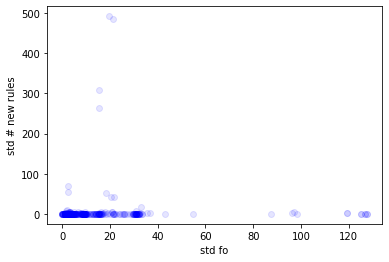

In [171]:
scatter(std_fo, std_rules, 'std fo', 'std # new rules')

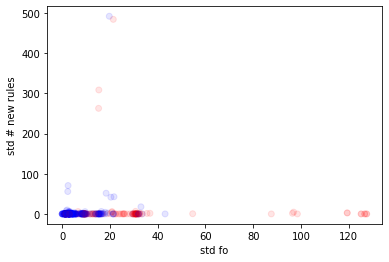

In [172]:
scatter_singleton2(std_fo, std_rules, 'std fo', 'std # new rules')

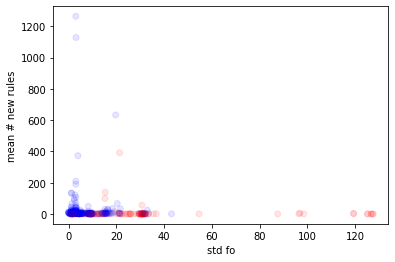

In [173]:
scatter_singleton2(std_fo, mean_rules, 'std fo', 'mean # new rules')

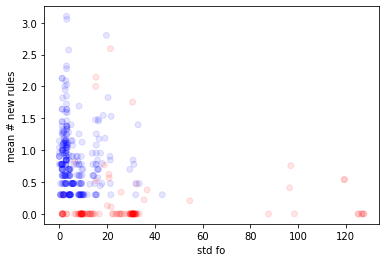

In [174]:
scatter_singleton2(std_fo, mean_rules_log10, 'std fo', 'mean # new rules')

In [ ]:
# bokeh plot:

d1 = std_fo
d2 = std_rules

output_file("annotated_plot.html")
p = figure(plot_width=800, plot_height=800, title="std fo vs. std # new rules")

# Add annotations
# source = {'x': list(group12iter.values()), 'y': y_values, 'label': ['X' + str(key) for key in group12iter.keys()]}
key, data1, data2 = todata(d1, d2)
source = {'x': data1, 'y': data2, 'label': [f"X{key} " + x2name.get(key, 'no X name') for key in key]}
p.scatter('x', 'y', source=source, size=10, color='blue')

# Add hover tool
hover = HoverTool()
hover.tooltips = [("fold", "@label")]
p.add_tools(hover)

# Customize plot
p.xaxis.axis_label = 'std fo'
p.yaxis.axis_label = 'std # new rules'
p.xaxis.ticker = [50, 100, 150, 200, 250, 300, 350]  # Convert range to list
p.xgrid.grid_line_color = None

# Show the plot
show(p)

In [ ]:
# bokeh plot: color singleton red

d1 = std_fo
d2 = std_rules

output_file("annotated_plot.html")
p = figure(plot_width=800, plot_height=800, title="std fo vs. std # new rules")

# Add annotations
# source = {'x': list(group12iter.values()), 'y': y_values, 'label': ['X' + str(key) for key in group12iter.keys()]}
valid_keys, data1, data2 = todata(d1, d2)

bools = [key in singleton2 for key in valid_keys]
keys_true = [key for key, flag in zip(valid_keys, bools) if flag]
keys_false = [key for key, flag in zip(valid_keys, bools) if not flag]
data1_true = [value for value, flag in zip(data1, bools) if flag]
data2_true = [value for value, flag in zip(data2, bools) if flag]
data1_false = [value for value, flag in zip(data1, bools) if not flag]
data2_false = [value for value, flag in zip(data2, bools) if not flag]

source = {'x': data1_false, 'y': data2_false, 'label': [f"X{key} " + x2name.get(key, 'no X name') for key in keys_false]}
p.scatter('x', 'y', source=source, size=10, color='blue', alpha=0.5)
source = {'x': data1_true, 'y': data2_true, 'label': [f"X{key} " + x2name.get(key, 'no X name') for key in keys_true]}
p.scatter('x', 'y', source=source, size=10, color='red', alpha=0.5)

# Add hover tool
hover = HoverTool()
hover.tooltips = [("fold", "@label")]
p.add_tools(hover)

# Customize plot
p.xaxis.axis_label = 'std fo'
p.yaxis.axis_label = 'std # new rules'
p.xaxis.ticker = [50, 100, 150, 200, 250, 300, 350]  # Convert range to list
p.xgrid.grid_line_color = None

# Show the plot
show(p)

In [ ]:
# $
# bokeh plot: color singleton red

d1 = std_fo
d2 = mean_rules_log10

output_file("annotated_plot.html")
p = figure(plot_width=800, plot_height=800, title="std fo vs. log10(mean # new rules)")

# Add annotations
# source = {'x': list(group12iter.values()), 'y': y_values, 'label': ['X' + str(key) for key in group12iter.keys()]}
valid_keys, data1, data2 = todata(d1, d2)

bools = [key in singleton2 for key in valid_keys]
keys_true = [key for key, flag in zip(valid_keys, bools) if flag]
keys_false = [key for key, flag in zip(valid_keys, bools) if not flag]
data1_true = [value for value, flag in zip(data1, bools) if flag]
data2_true = [value for value, flag in zip(data2, bools) if flag]
data1_false = [value for value, flag in zip(data1, bools) if not flag]
data2_false = [value for value, flag in zip(data2, bools) if not flag]

source = {'x': data1_false, 'y': data2_false, 'label': [f"X{key} " + x2name.get(key, 'no X name') for key in keys_false]}
p.scatter('x', 'y', source=source, size=10, color='blue', alpha=0.5)
source = {'x': data1_true, 'y': data2_true, 'label': [f"X{key} " + x2name.get(key, 'no X name') for key in keys_true]}
p.scatter('x', 'y', source=source, size=10, color='red', alpha=0.5)

# Add hover tool
hover = HoverTool()
hover.tooltips = [("fold", "@label")]
p.add_tools(hover)

# Customize plot
p.xaxis.axis_label = 'std fo'
p.yaxis.axis_label = 'log10(mean # new rules)'
p.xaxis.ticker = [50, 100, 150, 200, 250, 300, 350]  # Convert range to list
p.xgrid.grid_line_color = None

# Show the plot
show(p)

In [175]:
group1 & singleton2

{'2492', '253', '328', '3997', '4011', '4952', '602', '7523', '7584'}

In [ ]:
# $
# bokeh plot: color group1 orange

d1 = std_fo
d2 = mean_rules_log10

output_file("annotated_plot.html")
p = figure(plot_width=800, plot_height=800, title="std fo vs. log10(mean # new rules)")

# Add annotations
# source = {'x': list(group12iter.values()), 'y': y_values, 'label': ['X' + str(key) for key in group12iter.keys()]}
valid_keys, data1, data2 = todata(d1, d2)

bools = [key in group1 for key in valid_keys]
keys_true = [key for key, flag in zip(valid_keys, bools) if flag]
keys_false = [key for key, flag in zip(valid_keys, bools) if not flag]
data1_true = [value for value, flag in zip(data1, bools) if flag]
data2_true = [value for value, flag in zip(data2, bools) if flag]
data1_false = [value for value, flag in zip(data1, bools) if not flag]
data2_false = [value for value, flag in zip(data2, bools) if not flag]

source = {'x': data1_false, 'y': data2_false, 'label': [f"X{key} " + x2name.get(key, 'no X name') for key in keys_false]}
p.scatter('x', 'y', source=source, size=10, color='blue', alpha=0.5)
source = {'x': data1_true, 'y': data2_true, 'label': [f"X{key} " + x2name.get(key, 'no X name') for key in keys_true]}
p.scatter('x', 'y', source=source, size=10, color='orange', alpha=0.5)

# Add hover tool
hover = HoverTool()
hover.tooltips = [("fold", "@label")]
p.add_tools(hover)

# Customize plot
p.xaxis.axis_label = 'std fo'
p.yaxis.axis_label = 'log10(mean # new rules)'
p.xaxis.ticker = [50, 100, 150, 200, 250, 300, 350]  # Convert range to list
p.xgrid.grid_line_color = None

# Show the plot
show(p)

In [ ]:
# $
# bokeh plot: color (group1 & singleton) magenta

d1 = std_fo
d2 = mean_rules_log10

output_file("annotated_plot.html")
p = figure(plot_width=800, plot_height=800, title="std fo vs. log10(mean # new rules)")

# Add annotations
# source = {'x': list(group12iter.values()), 'y': y_values, 'label': ['X' + str(key) for key in group12iter.keys()]}
valid_keys, data1, data2 = todata(d1, d2)

bools = [key in (group1 & singleton) for key in valid_keys]
keys_true = [key for key, flag in zip(valid_keys, bools) if flag]
keys_false = [key for key, flag in zip(valid_keys, bools) if not flag]
data1_true = [value for value, flag in zip(data1, bools) if flag]
data2_true = [value for value, flag in zip(data2, bools) if flag]
data1_false = [value for value, flag in zip(data1, bools) if not flag]
data2_false = [value for value, flag in zip(data2, bools) if not flag]

source = {'x': data1_false, 'y': data2_false, 'label': [f"X{key} " + x2name.get(key, 'no X name') for key in keys_false]}
p.scatter('x', 'y', source=source, size=10, color='blue', alpha=0.5)
source = {'x': data1_true, 'y': data2_true, 'label': [f"X{key} " + x2name.get(key, 'no X name') for key in keys_true]}
p.scatter('x', 'y', source=source, size=10, color='magenta', alpha=0.5)

# Add hover tool
hover = HoverTool()
hover.tooltips = [("fold", "@label")]
p.add_tools(hover)

# Customize plot
p.xaxis.axis_label = 'std fo'
p.yaxis.axis_label = 'log10(mean # new rules)'
p.xaxis.ticker = [50, 100, 150, 200, 250, 300, 350]  # Convert range to list
p.xgrid.grid_line_color = None

# Show the plot
show(p)

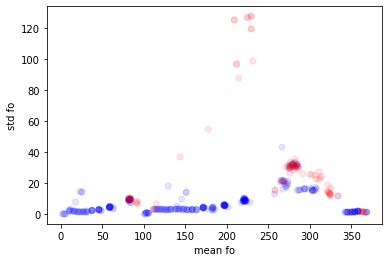

In [176]:
scatter_singleton2(mean_fo, std_fo, 'mean fo', 'std fo')

In [ ]:
# $
# bokeh plot: color singleton red

d1 = mean_fo
d2 = std_fo

output_file("annotated_plot.html")
p = figure(plot_width=800, plot_height=800, title="mean fo vs. std fo")

# Add annotations
# source = {'x': list(group12iter.values()), 'y': y_values, 'label': ['X' + str(key) for key in group12iter.keys()]}
valid_keys, data1, data2 = todata(d1, d2)

bools = [key in singleton for key in valid_keys]
keys_true = [key for key, flag in zip(valid_keys, bools) if flag]
keys_false = [key for key, flag in zip(valid_keys, bools) if not flag]
data1_true = [value for value, flag in zip(data1, bools) if flag]
data2_true = [value for value, flag in zip(data2, bools) if flag]
data1_false = [value for value, flag in zip(data1, bools) if not flag]
data2_false = [value for value, flag in zip(data2, bools) if not flag]

source = {'x': data1_false, 'y': data2_false, 'label': [f"X{key} " + x2name.get(key, 'no X name') for key in keys_false]}
p.scatter('x', 'y', source=source, size=10, color='blue', alpha=0.5)
source = {'x': data1_true, 'y': data2_true, 'label': [f"X{key} " + x2name.get(key, 'no X name') for key in keys_true]}
p.scatter('x', 'y', source=source, size=10, color='red', alpha=0.5)

# Add hover tool
hover = HoverTool()
hover.tooltips = [("fold", "@label")]
p.add_tools(hover)

# Customize plot
p.xaxis.axis_label = 'mean fo'
p.yaxis.axis_label = 'std fo'
p.xaxis.ticker = [50, 100, 150, 200, 250, 300, 350]  # Convert range to list
p.xgrid.grid_line_color = None

# Show the plot
show(p)

In [ ]:
# $
# bokeh plot: color group1 orange

d1 = mean_fo
d2 = std_fo

output_file("annotated_plot.html")
p = figure(plot_width=800, plot_height=800, title="mean fo vs. std fo")

# Add annotations
# source = {'x': list(group12iter.values()), 'y': y_values, 'label': ['X' + str(key) for key in group12iter.keys()]}
valid_keys, data1, data2 = todata(d1, d2)

bools = [key in group1 for key in valid_keys]
keys_true = [key for key, flag in zip(valid_keys, bools) if flag]
keys_false = [key for key, flag in zip(valid_keys, bools) if not flag]
data1_true = [value for value, flag in zip(data1, bools) if flag]
data2_true = [value for value, flag in zip(data2, bools) if flag]
data1_false = [value for value, flag in zip(data1, bools) if not flag]
data2_false = [value for value, flag in zip(data2, bools) if not flag]

source = {'x': data1_false, 'y': data2_false, 'label': [f"X{key} " + x2name.get(key, 'no X name') for key in keys_false]}
p.scatter('x', 'y', source=source, size=10, color='blue', alpha=0.5)
source = {'x': data1_true, 'y': data2_true, 'label': [f"X{key} " + x2name.get(key, 'no X name') for key in keys_true]}
p.scatter('x', 'y', source=source, size=10, color='orange', alpha=0.5)

# Add hover tool
hover = HoverTool()
hover.tooltips = [("fold", "@label")]
p.add_tools(hover)

# Customize plot
p.xaxis.axis_label = 'mean fo'
p.yaxis.axis_label = 'std fo'
p.xaxis.ticker = [50, 100, 150, 200, 250, 300, 350]  # Convert range to list
p.xgrid.grid_line_color = None

# Show the plot
show(p)

In [ ]:
# $
# bokeh plot: color (group1 & singleton) magenta

d1 = mean_fo
d2 = std_fo

output_file("annotated_plot.html")
p = figure(plot_width=800, plot_height=800, title="mean fo vs. std fo")

# Add annotations
# source = {'x': list(group12iter.values()), 'y': y_values, 'label': ['X' + str(key) for key in group12iter.keys()]}
valid_keys, data1, data2 = todata(d1, d2)

bools = [key in (group1 & singleton) for key in valid_keys]
keys_true = [key for key, flag in zip(valid_keys, bools) if flag]
keys_false = [key for key, flag in zip(valid_keys, bools) if not flag]
data1_true = [value for value, flag in zip(data1, bools) if flag]
data2_true = [value for value, flag in zip(data2, bools) if flag]
data1_false = [value for value, flag in zip(data1, bools) if not flag]
data2_false = [value for value, flag in zip(data2, bools) if not flag]

source = {'x': data1_false, 'y': data2_false, 'label': [f"X{key} " + x2name.get(key, 'no X name') for key in keys_false]}
p.scatter('x', 'y', source=source, size=10, color='blue', alpha=0.5)
source = {'x': data1_true, 'y': data2_true, 'label': [f"X{key} " + x2name.get(key, 'no X name') for key in keys_true]}
p.scatter('x', 'y', source=source, size=10, color='magenta', alpha=0.5)

# Add hover tool
hover = HoverTool()
hover.tooltips = [("fold", "@label")]
p.add_tools(hover)

# Customize plot
p.xaxis.axis_label = 'mean fo'
p.yaxis.axis_label = 'std fo'
p.xaxis.ticker = [50, 100, 150, 200, 250, 300, 350]  # Convert range to list
p.xgrid.grid_line_color = None

# Show the plot
show(p)

In [177]:
x2rulesNum_log10 = {key:np.log10(value) for key, value in x2rulesNum.items()}

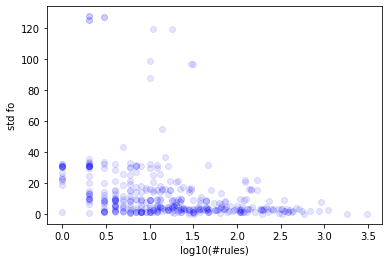

In [178]:
scatter(x2rulesNum_log10, std_fo, 'log10(#rules)', 'std fo')

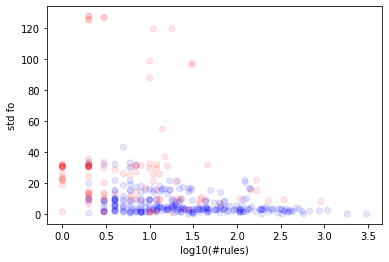

In [179]:
scatter_singleton2(x2rulesNum_log10, std_fo, 'log10(#rules)', 'std fo')

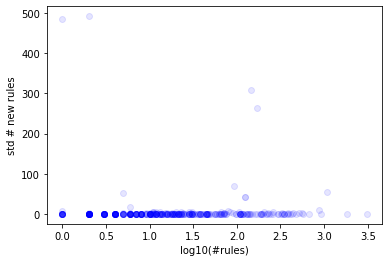

In [180]:
scatter(x2rulesNum_log10, std_rules, 'log10(#rules)', 'std # new rules')

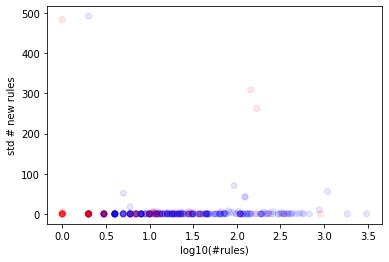

In [181]:
scatter_singleton2(x2rulesNum_log10, std_rules, 'log10(#rules)', 'std # new rules')

In [ ]:
# bokeh plot:
d1 = x2rulesNum_log10
d2 = std_fo

output_file("annotated_plot.html")
p = figure(plot_width=800, plot_height=800, title="log10(#rules) vs. std fo")

# Add annotations
# source = {'x': list(group12iter.values()), 'y': y_values, 'label': ['X' + str(key) for key in group12iter.keys()]}
valid_keys, data1, data2 = todata(d1, d2)

bools = [key in singleton2 for key in valid_keys]
keys_true = [key for key, flag in zip(valid_keys, bools) if flag]
keys_false = [key for key, flag in zip(valid_keys, bools) if not flag]
data1_true = [value for value, flag in zip(data1, bools) if flag]
data2_true = [value for value, flag in zip(data2, bools) if flag]
data1_false = [value for value, flag in zip(data1, bools) if not flag]
data2_false = [value for value, flag in zip(data2, bools) if not flag]

source = {'x': data1_false, 'y': data2_false, 'label': [f"X{key} " + x2name.get(key, 'no X name') for key in keys_false]}
p.scatter('x', 'y', source=source, size=10, color='blue', alpha=0.5)
source = {'x': data1_true, 'y': data2_true, 'label': [f"X{key} " + x2name.get(key, 'no X name') for key in keys_true]}
p.scatter('x', 'y', source=source, size=10, color='red', alpha=0.5)

# Add hover tool
hover = HoverTool()
hover.tooltips = [("fold", "@label")]
p.add_tools(hover)

# Customize plot
p.xaxis.axis_label = 'log10(#rules)'
p.yaxis.axis_label = 'std fo'
p.xaxis.ticker = [50, 100, 150, 200, 250, 300, 350]  # Convert range to list
p.xgrid.grid_line_color = None

# Show the plot
show(p)

In [ ]:
# bokeh plot:
d1 = x2rulesNum_log10
d2 = std_rules

output_file("annotated_plot.html")
p = figure(plot_width=800, plot_height=800, title="log10(# rules) vs. std rules")

# Add annotations
# source = {'x': list(group12iter.values()), 'y': y_values, 'label': ['X' + str(key) for key in group12iter.keys()]}
key, data1, data2 = todata(d1, d2)
source = {'x': data1, 'y': data2, 'label': [f"X{key} " + x2name.get(key, 'no X name') for key in key]}
p.scatter('x', 'y', source=source, size=10, color='blue')

# Add hover tool
hover = HoverTool()
hover.tooltips = [("fold", "@label")]
p.add_tools(hover)

# Customize plot
p.xaxis.axis_label = 'log10(# rules)'
p.yaxis.axis_label = 'std rules'
p.xaxis.ticker = [50, 100, 150, 200, 250, 300, 350]  # Convert range to list
p.xgrid.grid_line_color = None

# Show the plot
show(p)

### log10(# rules) vs. burst_size_Ave

In [ ]:
fo2cpdNum_list = []  # NOT cummulative
for run in fo2cpds_list:                   
    fo2cpdNum = {key:len(values) for key, values in run.items()}
    fo2cpdNum_list.append(fo2cpdNum)

In [ ]:
fold2cpdsNum_list = []  # list of 64 dicts
for i in range(0,63):
    fold2cpdsNum = {}
    
    for fold in fold2fo_list[i].keys():
        if fold != 'fold_independent':
            fo = fold2fo_list[i][fold]
            fold2cpdsNum[fold] = fo2cpdNum_list[i].get(fo, 0)  # connect fold with # new cpds
    
    fold2cpdsNum_list.append(fold2cpdsNum)

In [ ]:
fold2cpdsNum_64runs = {key:[] for key in fold2cpdsNum_list[0].keys()}  # empty dict

for run in fold2cpdsNum_list:
    for fold, num in run.items():
        fold2cpdsNum_64runs[fold].append(num)

In [ ]:
fold2cpdsNum_64runs['3997']

In [ ]:
fold2cpdsNum_64runs_MeanStd = {key:[np.mean(values), np.std(values)] for key, values in fold2cpdsNum_64runs.items()}

In [ ]:
mean_cpd = {key: values[0] for key, values in fold2cpdsNum_64runs_MeanStd.items()}
std_cpd = {key: values[1] for key, values in fold2cpdsNum_64runs_MeanStd.items()}

In [ ]:
scatter(x2rulesNum_log10, mean_cpd, 'log10(#rules)', 'mean #cpd discovered')

In [ ]:
# bokeh plot:
d1 = x2rulesNum_log10
d2 = mean_cpd

output_file("annotated_plot.html")
p = figure(plot_width=800, plot_height=800, title="log10(# rules) vs. mean #cpd discovered")

# Add annotations
# source = {'x': list(group12iter.values()), 'y': y_values, 'label': ['X' + str(key) for key in group12iter.keys()]}
key, data1, data2 = todata(d1, d2)
source = {'x': data1, 'y': data2, 'label': [f"X{key} " + x2name.get(key, 'no X name') for key in key]}
p.scatter('x', 'y', source=source, size=10, color='blue')

# Add hover tool
hover = HoverTool()
hover.tooltips = [("fold", "@label")]
p.add_tools(hover)

# Customize plot
p.xaxis.axis_label = 'log10(# rules)'
p.yaxis.axis_label = 'mean #cpd discovered'
p.xaxis.ticker = [50, 100, 150, 200, 250, 300, 350]  # Convert range to list
p.xgrid.grid_line_color = None

# Show the plot
show(p)

In [ ]:
# bokeh plot:
d1 = x2rulesNum_log10
d2 = std_cpd

output_file("annotated_plot.html")
p = figure(plot_width=800, plot_height=800, title="log10(# rules) vs. std #cpd discovered")

# Add annotations
# source = {'x': list(group12iter.values()), 'y': y_values, 'label': ['X' + str(key) for key in group12iter.keys()]}
key, data1, data2 = todata(d1, d2)
source = {'x': data1, 'y': data2, 'label': [f"X{key} " + x2name.get(key, 'no X name') for key in key]}
p.scatter('x', 'y', source=source, size=10, color='blue')

# Add hover tool
hover = HoverTool()
hover.tooltips = [("fold", "@label")]
p.add_tools(hover)

# Customize plot
p.xaxis.axis_label = 'log10(# rules)'
p.yaxis.axis_label = 'std #cpd discovered'
p.xaxis.ticker = [50, 100, 150, 200, 250, 300, 350]  # Convert range to list
p.xgrid.grid_line_color = None

# Show the plot
show(p)

In [ ]:
df_rule

In [ ]:
len(df_rn.index)

In [ ]:
len(df_rule.index)
# (rn, rule) : folditer
# multiple same rn (with different rule) are possible
# does not include seed reactions; records which new rule was added 
# new rule addition ≠ new rn addition (could be discovery of alternative rule)

In [ ]:
df_rule.index

## Is arg always after Oxy in 64 runs?

In [ ]:
cpd2name['C00062']

In [ ]:
pos = 0
for i in range(0, len(list(df_cpd.loc['C00062']))):
    print(list(df_cpd.loc['C00062'])[i] - list(df_cpd.loc['C00007'])[i])
    if list(df_cpd.loc['C00062'])[i] - list(df_cpd.loc['C00007'])[i] > 0:
        pos +=1
pos

In [ ]:
# Trp

for i in range(0, len(list(df_cpd.loc['C00078']))):
    print(list(df_cpd.loc['C00078'])[i] - list(df_cpd.loc['C00007'])[i])

In [ ]:
np.std(df_cpd.loc['C00062']) # Arg

In [ ]:
np.std(df_cpd.loc['C00078'])  # Trp

In [ ]:
np.std(df_cpd.loc['C00007'])  # O2

In [ ]:
np.std(df_cpd.loc['C00079']) # Phe/Tyr  

In [ ]:
np.min(df_cpd.loc['C00062'])  # Arg

In [ ]:
np.min(df_cpd.loc['C00078'])  # Trp

In [ ]:
np.min(df_cpd.loc['C00007'])  # O2

In [ ]:
np.min(df_cpd.loc['C00079']) # Phe/Tyr

# singletons in original

In [182]:
mean_fo_1000 = {key: values[0] for key, values in x2foAveNONE.items()}

In [183]:
std_fo_1000 = {key: values[1] for key, values in x2foAveNONE.items()}

In [184]:
df_rule_1000 = pd.read_csv('../rules_folditer_optimal_1000runs.csv', index_col=0)

In [185]:
fo2rules_list_1000 = []
for run in df_rule_1000.columns:  #  1000 runs
    fo2rules = {}
    for c, order in df_rule_1000[run].items():
        if order not in fo2rules.keys():
            fo2rules[order] = [c]
        else:
            fo2rules[order].append(c)
    fo2rules_list_1000.append(fo2rules)
    
fo2ruleNum_list_1000 = []  # NOT cummulative
for run in fo2rules_list_1000:                   
    fo2ruleNum = {key:len(values) for key, values in run.items()}
    fo2ruleNum_list_1000.append(fo2ruleNum)

In [186]:
df_fold_1000 = pd.read_csv('../folds_folditer_optimal_1000runs.csv', index_col=0)

fold2fo_list_1000 = []
for run in df_fold_1000.columns:  # 1000 runs
    fold2fo = {}
    for fold, order in df_fold_1000[run].items():
        fold2fo[fold] = order
    fold2fo_list_1000.append(fold2fo)

In [187]:
fold2rulesNum_list_1000 = []  # list of 1000 dicts
for i in range(0,999):
    fold2rulesNum = {}
    
    for fold in fold2fo_list_1000[i].keys():
        if fold != 'fold_independent':
            fo = fold2fo_list_1000[i][fold]
            fold2rulesNum[fold] = fo2ruleNum_list_1000[i][fo]  # connect fold with # new rules
    
    fold2rulesNum_list_1000.append(fold2rulesNum)

In [188]:
fold2rulesNum_1000runs = {key:[] for key in fold2rulesNum_list_1000[0].keys()}  # empty dict

for run in fold2rulesNum_list_1000:
    for fold, num in run.items():
        fold2rulesNum_1000runs[fold].append(num)

In [189]:
singleton3 = copy.deepcopy(singleton1)
count = 0
for x, nums in fold2rulesNum_1000runs.items():
    if 1 in nums:
        print(x, nums.count(1)/len(nums), x in singleton1)
        singleton3.add(x)
        if nums.count(1)/len(nums) == 1.0:
            count+=1

2484 1.0 False
328 1.0 False
2498 1.0 False
7573 1.0 False
64 1.0 False
3847 1.0 False
4021 1.0 False
2485 1.0 False
7552 1.0 False
7520 1.0 False
149 1.0 False
103 1.0 False
2493 1.0 False
7541 1.0 False
708 1.0 False
7523 1.0 False
164 1.0 False
285 1.0 False
302 1.0 False
3651 1.0 False
3374 1.0 False
144 1.0 False
4952 1.0 False
602 1.0 False
223 0.4924924924924925 False
4019 0.4924924924924925 False
7521 1.0 False
5069 1.0 False
237 1.0 False
3687 1.0 False
4011 0.4494494494494494 False
7584 0.5245245245245245 False
4111 1.0 True
309 1.0 False
813 0.3383383383383383 False
235 1.0 False
7551 1.0 False
633 1.0 False
842 1.0 False
6096 1.0 True
558 1.0 True
2496 1.0 False
650 1.0 True
4029 1.0 False
316 0.7387387387387387 False
102 0.26126126126126126 False
214 0.5125125125125125 False
107 1.0 False
814 1.0 True
1114 1.0 False
5067 1.0 True
3685 1.0 True
258 1.0 False
4022 1.0 False
7562 1.0 False
284 1.0 True
7604 1.0 False
154 1.0 False
525 1.0 False
4335 1.0 False
876 1.0 False
11

In [190]:
print(count, len(singleton3))
# 99 obligate singletons, 119 singletons

99 119


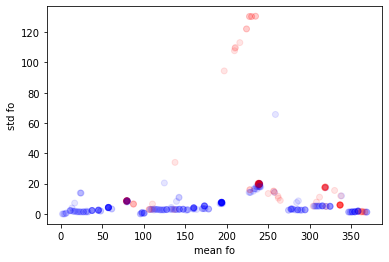

In [191]:
scatter_singleton3(mean_fo_1000, std_fo_1000, 'mean fo', 'std fo')

# annotating fo vs. cumm cpd plot with key cpds

In [192]:
# before
fo2cpds_list_before = []
for run in df_optimal.columns:  # 1000 optimal runs
    fo2cpds = {}
    for c, order in df_optimal[run].items():
        if order not in fo2cpds.keys():
            fo2cpds[order] = [c]
        else:
            fo2cpds[order].append(c)
    fo2cpds_list_before.append(fo2cpds)
    
fo2cpdNum_list_before = []
for run in fo2cpds_list_before:                   
    fo2cpdNum = {}
    cumm = 0
    for i in range(0, max(run.keys())): 
        if i in run.keys():
            cumm += len(run[i])
        fo2cpdNum[i] = cumm
    fo2cpdNum_list_before.append(fo2cpdNum)

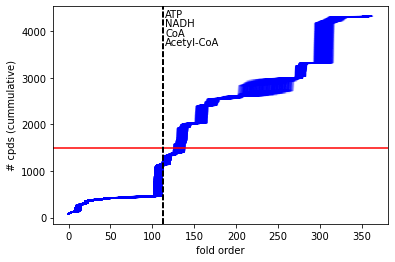

In [193]:
for run in fo2cpdNum_list_before:
    plt.plot(run.keys(), run.values(), color='blue', alpha = 0.1,zorder=2)

plt.axhline(y=1500, color='r')

cpds = ['C00002', 'C00004', 'C00010', 'C00024']
h = 4300
for c in cpds:
    plt.axvline(x=np.mean(df_cpd.loc[c]), color='k', linestyle='--')
    plt.annotate(cpd2name[c], xy=(np.mean(df_cpd.loc[c])+3,h), fontsize=10, color="black")
    h -= 200

plt.xlabel('fold order')
plt.ylabel('# cpds (cummulative)')

# plt.savefig('fold_order_vs_cumm_cpds_pro_pero.svg', dpi=300, bbox_inches = 'tight')
plt.show()

In [ ]:
# can't use fold_gated data for LOO data!